# GPU STOMP with STUMPY

This notebook is a thesis-ready starting point for running a GPU-accelerated matrix profile on the processed BTCUSDT 1-minute dataset.

It keeps the same project-relative path pattern as the existing CPU notebook, but swaps the main compute step to `stumpy.gpu_stump` when CUDA is available.

In [1]:
from numba import cuda

print("CUDA available:", cuda.is_available())

if cuda.is_available():
    device = cuda.get_current_device()
    print("GPU:", device.name)
else:
    print("No CUDA GPU detected")

CUDA available: True
GPU: b'NVIDIA GeForce RTX 3060 Laptop GPU'


In [2]:
# Check CUDA visibility and run a basic GPU matrix calculation (A + B = C)

import numpy as np


if not cuda.is_available():
    print("CUDA accessible: False")
else:
    gpu_name = device.name.decode() if isinstance(device.name, bytes) else str(device.name)
    print("CUDA accessible: True")
    print(f"Active GPU: {gpu_name}")

    @cuda.jit
    def mat_add(a, b, c):
        i, j = cuda.grid(2)
        if i < c.shape[0] and j < c.shape[1]:
            c[i, j] = a[i, j] + b[i, j]

    # Small test matrices
    A = np.arange(16, dtype=np.float32).reshape(4, 4)
    B = np.ones((4, 4), dtype=np.float32) * 2
    C = np.zeros((4, 4), dtype=np.float32)

    # Move to GPU
    dA = cuda.to_device(A)
    dB = cuda.to_device(B)
    dC = cuda.to_device(C)

    # Launch kernel
    threads_per_block = (16, 16)
    blocks_per_grid_x = (C.shape[0] + threads_per_block[0] - 1) // threads_per_block[0]
    blocks_per_grid_y = (C.shape[1] + threads_per_block[1] - 1) // threads_per_block[1]
    mat_add[(blocks_per_grid_x, blocks_per_grid_y), threads_per_block](dA, dB, dC)

    # Copy result back
    C_result = dC.copy_to_host()

    print("A:\n", A)
    print("B:\n", B)
    print("C (GPU result):\n", C_result)
    print("Result correct:", np.allclose(C_result, A + B))

CUDA accessible: True
Active GPU: NVIDIA GeForce RTX 3060 Laptop GPU


c:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis\.thesis-env\Lib\site-packages\numba\cuda\dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


A:
 [[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]
 [12. 13. 14. 15.]]
B:
 [[2. 2. 2. 2.]
 [2. 2. 2. 2.]
 [2. 2. 2. 2.]
 [2. 2. 2. 2.]]
C (GPU result):
 [[ 2.  3.  4.  5.]
 [ 6.  7.  8.  9.]
 [10. 11. 12. 13.]
 [14. 15. 16. 17.]]
Result correct: True


## 1. Setup

If needed, install the repository dependencies from the project root:

```bash
pip install -r requirements.txt
```

For GPU execution, the Python environment also needs a working CUDA-capable setup that `numba.cuda` can detect.

In [3]:
from pathlib import Path
from time import perf_counter
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import stumpy

plt.style.use("seaborn-v0_8-whitegrid")

In [4]:
# Resolve paths relative to this notebook location.
project_root = Path("../../").resolve()
data_path = project_root / "data" / "processed" / "crypto" / "1min" / "BTCUSDT_1m_processed.parquet"

if not data_path.exists():
    raise FileNotFoundError(f"Processed dataset was not found at: {data_path}")

data_path

WindowsPath('C:/Users/learn/OneDrive/Desktop/Masters Thesis/MastersThesis/data/processed/crypto/1min/BTCUSDT_1m_processed.parquet')

## 2. Load the processed BTCUSDT data

In [5]:
df = pd.read_parquet(data_path)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['timestamp'].min()} -> {df['timestamp'].max()}")

Rows: 4,502,648
Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'log_return', 'pct_return', 'volatility_30m', 'volatility_60m', 'volatility_240m', 'realized_volatility_60m']
Date range: 2017-08-17 04:00:00+00:00 -> 2026-03-15 23:59:00+00:00


## 3. Select a signal and one-year analysis window

`log_return` is a sensible first univariate signal for matrix profiling because it reduces long-run price trend dominance.

This notebook is configured to run on a full calendar year so the GPU path is used for a genuinely large experiment rather than a short debug sample.

In [6]:
import numpy as np
import pandas as pd

candidate_column = "log_return"
analysis_year = 2025
year_start = pd.Timestamp(f"{analysis_year}-01-01 00:00:00", tz="UTC")
year_end = pd.Timestamp(f"{analysis_year + 1}-01-01 00:00:00", tz="UTC")

if candidate_column not in df.columns:
    raise KeyError(f"Expected column '{candidate_column}' was not found.")

sample_df = (
    df[["timestamp", "open", "high", "low", "close", "volume", candidate_column]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_values("timestamp")
    .reset_index(drop=True)
    .rename(columns={candidate_column: "signal"})
)

sample_df = sample_df.loc[
    (sample_df["timestamp"] >= year_start) & (sample_df["timestamp"] < year_end)
].reset_index(drop=True).copy()

if sample_df.empty:
    raise ValueError(
        f"No rows were found for analysis_year={analysis_year}. "
        "Check the dataset coverage before running the GPU profile."
    )

signal = sample_df["signal"].to_numpy(dtype=np.float64)

print(f"Analysis rows used in this notebook: {len(sample_df):,}")
print(f"Analysis date range: {sample_df['timestamp'].min()} -> {sample_df['timestamp'].max()}")
print("Columns in sample_df:", sample_df.columns.tolist())

Analysis rows used in this notebook: 525,600
Analysis date range: 2025-01-01 00:00:00+00:00 -> 2025-12-31 23:59:00+00:00
Columns in sample_df: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'signal']


In [7]:
print(f"Sample date range: {sample_df['timestamp'].min()} -> {sample_df['timestamp'].max()}")

Sample date range: 2025-01-01 00:00:00+00:00 -> 2025-12-31 23:59:00+00:00


## 4. Check GPU availability

If CUDA is visible to `numba`, the notebook will use `stumpy.gpu_stump`. Otherwise it falls back to `stumpy.stump` so you can still edit and validate the rest of the workflow.

In [8]:
gpu_available = False
gpu_error = None
gpu_name = None
gpu_total_memory_gb = None

try:
    from numba import cuda

    gpu_available = cuda.is_available()
    if gpu_available:
        device = cuda.get_current_device()
        gpu_name = device.name.decode() if isinstance(device.name, bytes) else device.name
        gpu_total_memory_gb = device.total_memory / (1024 ** 3)
except Exception as exc:
    gpu_error = repr(exc)

print(f"GPU available: {gpu_available}")
if gpu_name is not None:
    print(f"GPU name: {gpu_name}")
if gpu_total_memory_gb is not None:
    print(f"GPU memory (GB): {gpu_total_memory_gb:.2f}")
if gpu_error is not None:
    print(f"GPU probe error: {gpu_error}")

GPU available: True
GPU name: NVIDIA GeForce RTX 3060 Laptop GPU
GPU probe error: AttributeError('total_memory')


## 5. Run GPU STOMP

The `window` value is in minutes here because the dataset is 1-minute data. Adjust it to the motif duration you want to test.

In [9]:
window = 60
device_id = 0

if len(signal) <= window:
    raise ValueError("Signal length must be greater than the subsequence window.")

start = perf_counter()

if gpu_available:
    backend = "stumpy.gpu_stump"
    mp = stumpy.gpu_stump(signal, m=window, device_id=device_id)
else:
    backend = "stumpy.stump"
    warnings.warn(
        "CUDA GPU not available. Falling back to CPU STUMP so the notebook remains editable.",
        stacklevel=2,
    )
    mp = stumpy.stump(signal, m=window)

elapsed_seconds = perf_counter() - start

matrix_profile = np.asarray(mp[:, 0], dtype=np.float64)
nearest_neighbor_idx = np.asarray(mp[:, 1], dtype=np.int64)

print(f"Backend used: {backend}")
print(f"Window size: {window}")
print(f"Profile length: {len(matrix_profile):,}")
print(f"Elapsed seconds: {elapsed_seconds:,.2f}")

Backend used: stumpy.gpu_stump
Window size: 60
Profile length: 525,541
Elapsed seconds: 98.79


## 6. Inspect the matrix profile

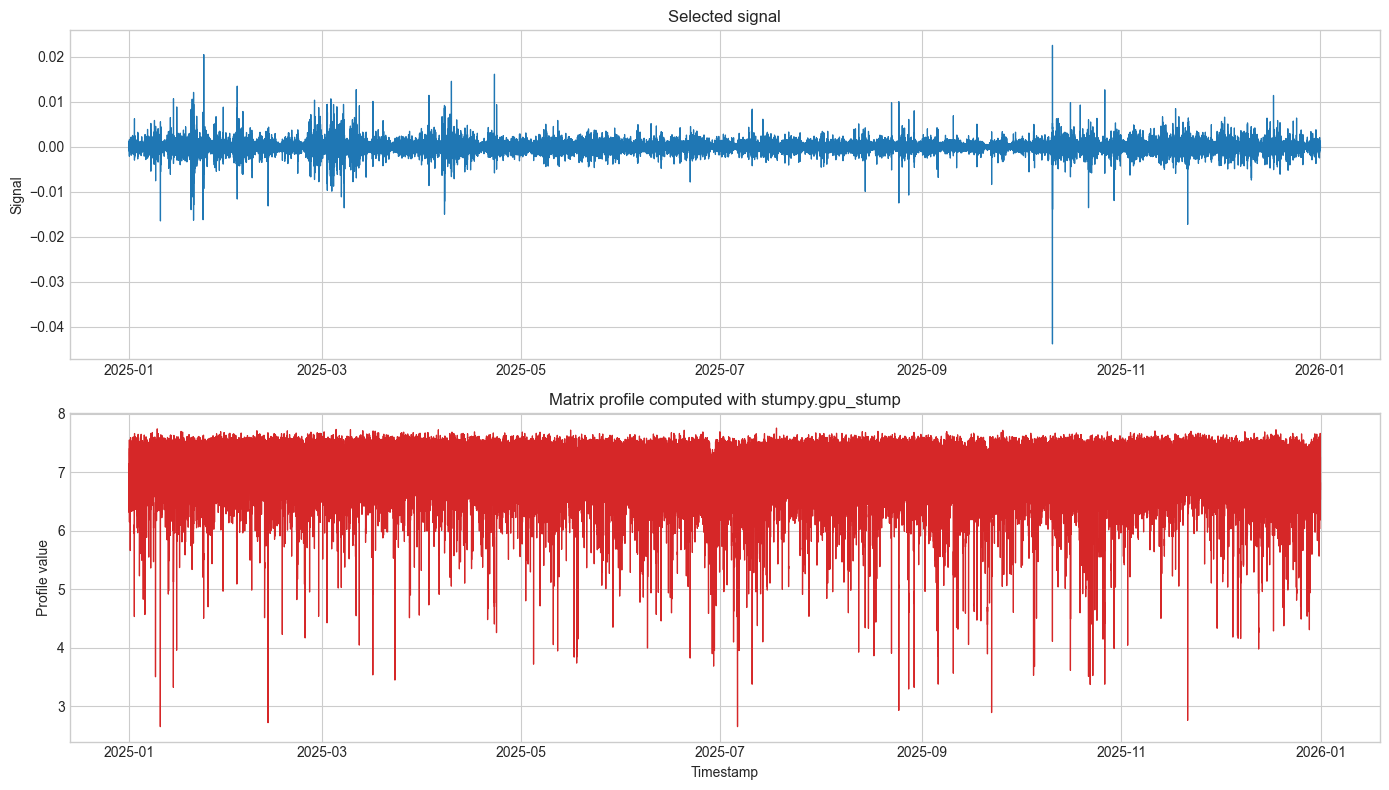

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(sample_df["timestamp"], sample_df["signal"], color="tab:blue", linewidth=0.9)
axes[0].set_title("Selected signal")
axes[0].set_ylabel("Signal")

profile_timestamps = sample_df["timestamp"].iloc[: len(matrix_profile)]
axes[1].plot(profile_timestamps, matrix_profile, color="tab:red", linewidth=0.9)
axes[1].set_title(f"Matrix profile computed with {backend}")
axes[1].set_ylabel("Profile value")
axes[1].set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

## 7. Extract top motifs and discords

In [11]:
def _overlaps(index_a: int, index_b: int, subseq_window: int) -> bool:
    return abs(index_a - index_b) < subseq_window


def top_non_overlapping_motifs(profile, neighbor_idx, subseq_window, k=5):
    motifs = []
    order = np.argsort(profile)

    for idx in order:
        if not np.isfinite(profile[idx]):
            continue

        nn_idx = int(neighbor_idx[idx])
        if nn_idx < 0:
            continue

        conflict = False
        for existing in motifs:
            if _overlaps(idx, existing["query_index"], subseq_window):
                conflict = True
                break
            if _overlaps(idx, existing["match_index"], subseq_window):
                conflict = True
                break
            if _overlaps(nn_idx, existing["query_index"], subseq_window):
                conflict = True
                break
            if _overlaps(nn_idx, existing["match_index"], subseq_window):
                conflict = True
                break

        if conflict:
            continue

        motifs.append(
            {
                "query_index": int(idx),
                "match_index": nn_idx,
                "profile_value": float(profile[idx]),
            }
        )

        if len(motifs) >= k:
            break

    return motifs


def top_non_overlapping_discords(profile, subseq_window, k=5):
    discords = []
    order = np.argsort(profile)[::-1]

    for idx in order:
        if not np.isfinite(profile[idx]):
            continue
        if any(_overlaps(idx, existing["index"], subseq_window) for existing in discords):
            continue

        discords.append({"index": int(idx), "profile_value": float(profile[idx])})
        if len(discords) >= k:
            break

    return discords


top_motifs = top_non_overlapping_motifs(matrix_profile, nearest_neighbor_idx, window, k=5)
top_discords = top_non_overlapping_discords(matrix_profile, window, k=5)

motif_df = pd.DataFrame(top_motifs)
if not motif_df.empty:
    motif_df["query_time"] = motif_df["query_index"].map(sample_df["timestamp"])
    motif_df["match_time"] = motif_df["match_index"].map(sample_df["timestamp"])

discord_df = pd.DataFrame(top_discords)
if not discord_df.empty:
    discord_df["timestamp"] = discord_df["index"].map(sample_df["timestamp"])

motif_df

,query_index,match_index,profile_value,query_time,match_time
0,13711,268369,2.653183,2025-01-10 12:31:00+00:00,2025-07-06 08:49:00+00:00
1,380463,339518,2.931639,2025-09-22 05:03:00+00:00,2025-08-24 18:38:00+00:00
2,346291,19471,3.324551,2025-08-29 11:31:00+00:00,2025-01-14 12:31:00+00:00
3,423964,466954,3.373826,2025-10-22 10:04:00+00:00,2025-11-21 06:34:00+00:00
4,430384,274818,3.378580,2025-10-26 21:04:00+00:00,2025-07-10 20:18:00+00:00


In [12]:
discord_df

,index,profile_value,timestamp
0,285557,7.756587,2025-07-18 07:17:00+00:00
1,12356,7.742789,2025-01-09 13:56:00+00:00
2,91260,7.733290,2025-03-05 09:00:00+00:00
3,97604,7.730010,2025-03-09 18:44:00+00:00
4,505923,7.728219,2025-12-18 08:03:00+00:00


## 8. Plot one motif pair

This is a compact starting visualization. Expand it if you want richer overlays or event annotations.

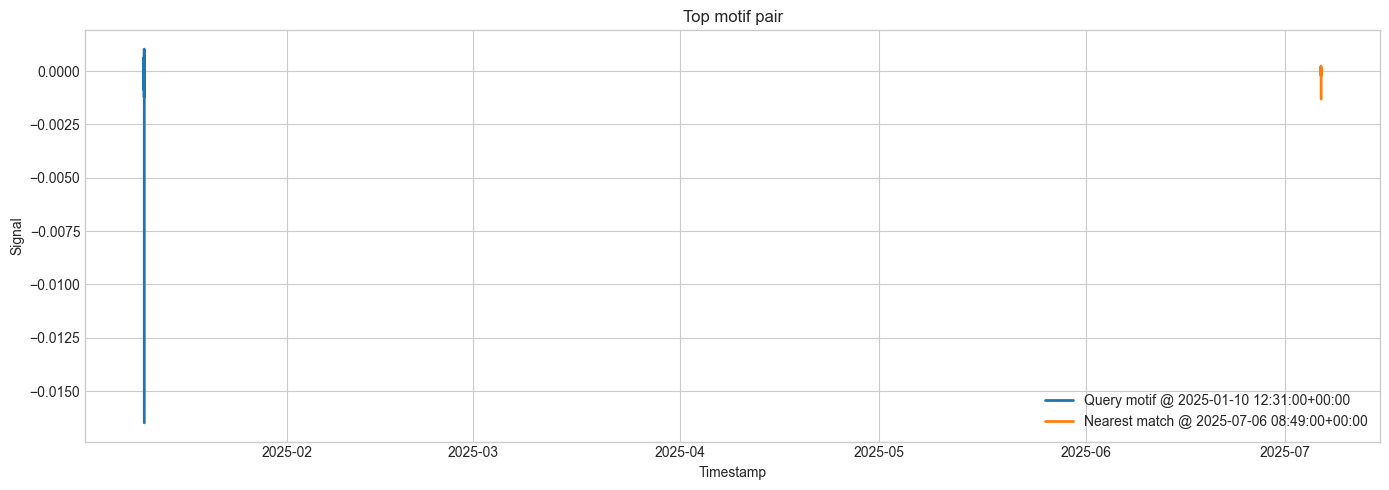

In [13]:
if motif_df.empty:
    print("No motif pair was selected.")
else:
    row = motif_df.iloc[0]
    query_slice = slice(int(row["query_index"]), int(row["query_index"]) + window)
    match_slice = slice(int(row["match_index"]), int(row["match_index"]) + window)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(
        sample_df["timestamp"].iloc[query_slice],
        sample_df["signal"].iloc[query_slice],
        label=f"Query motif @ {row['query_time']}",
        linewidth=2,
    )
    ax.plot(
        sample_df["timestamp"].iloc[match_slice],
        sample_df["signal"].iloc[match_slice],
        label=f"Nearest match @ {row['match_time']}",
        linewidth=2,
    )
    ax.set_title("Top motif pair")
    ax.set_ylabel("Signal")
    ax.set_xlabel("Timestamp")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 9. Notes for further editing

- Change `analysis_year` if you want to profile a different full-year slice.
- Benchmark several `window` values to see which motif duration is most interpretable for BTC returns.
- If you want a direct CPU vs GPU timing comparison, duplicate the compute cell and force one run with `stumpy.stump` and one with `stumpy.gpu_stump`.
- Once the univariate run is stable, you can branch from here into multivariate motif experiments.

# Build motif and discord tables with timestamps


In [14]:
# Build motif and discord summaries with timestamps

import numpy as np
import pandas as pd

top_k_motifs = 15
top_k_discords = 15
exclusion_zone = window // 2

matrix_profile = np.asarray(mp[:, 0], dtype=np.float64)
nearest_neighbor_idx = np.asarray(mp[:, 1], dtype=np.int64)

valid_mask = np.isfinite(matrix_profile)
valid_indices = np.where(valid_mask)[0]

print(f"Total subsequences evaluated: {len(matrix_profile):,}")
print(f"Finite matrix profile values: {valid_mask.sum():,}")
print(f"Invalid / inf values: {(~valid_mask).sum():,}")

# ---------- Motifs ----------
motif_rows = []
used = np.zeros(len(matrix_profile), dtype=bool)

for idx in np.argsort(matrix_profile):
    if not np.isfinite(matrix_profile[idx]):
        continue

    nn_idx = int(nearest_neighbor_idx[idx])
    if nn_idx < 0 or nn_idx == idx:
        continue

    # avoid heavy overlap between already selected motif windows
    left = max(0, idx - exclusion_zone)
    right = min(len(used), idx + exclusion_zone + 1)
    left_nn = max(0, nn_idx - exclusion_zone)
    right_nn = min(len(used), nn_idx + exclusion_zone + 1)

    if used[left:right].any() or used[left_nn:right_nn].any():
        continue

    motif_rows.append({
        "rank": len(motif_rows) + 1,
        "query_index": int(idx),
        "match_index": int(nn_idx),
        "profile_value": float(matrix_profile[idx]),
        "query_time": sample_df.iloc[idx]["timestamp"],
        "match_time": sample_df.iloc[nn_idx]["timestamp"],
        "query_end_time": sample_df.iloc[min(idx + window - 1, len(sample_df) - 1)]["timestamp"],
        "match_end_time": sample_df.iloc[min(nn_idx + window - 1, len(sample_df) - 1)]["timestamp"],
    })

    used[left:right] = True
    used[left_nn:right_nn] = True

    if len(motif_rows) >= top_k_motifs:
        break

motif_df = pd.DataFrame(motif_rows)

# ---------- Discords ----------
discord_rows = []
used_discord = np.zeros(len(matrix_profile), dtype=bool)

for idx in np.argsort(-matrix_profile):
    if not np.isfinite(matrix_profile[idx]):
        continue

    left = max(0, idx - exclusion_zone)
    right = min(len(used_discord), idx + exclusion_zone + 1)

    if used_discord[left:right].any():
        continue

    discord_rows.append({
        "rank": len(discord_rows) + 1,
        "index": int(idx),
        "profile_value": float(matrix_profile[idx]),
        "timestamp": sample_df.iloc[idx]["timestamp"],
        "end_time": sample_df.iloc[min(idx + window - 1, len(sample_df) - 1)]["timestamp"],
    })

    used_discord[left:right] = True

    if len(discord_rows) >= top_k_discords:
        break

discord_df = pd.DataFrame(discord_rows)

print(f"\nTop motifs found: {len(motif_df)}")
print(f"Top discords found: {len(discord_df)}")

Total subsequences evaluated: 525,541
Finite matrix profile values: 525,541
Invalid / inf values: 0

Top motifs found: 15
Top discords found: 15


## Print motif dates cleanly

In [15]:
# Print motif summary with dates

if motif_df.empty:
    print("No motifs found.")
else:
    print("TOP MOTIFS")
    print("=" * 120)
    for _, row in motif_df.iterrows():
        print(
            f"Rank {int(row['rank'])}: "
            f"Motif [{row['query_time']} -> {row['query_end_time']}] "
            f"(idx {int(row['query_index'])}:{int(row['query_index']) + window}) | "
            f"Neighbor [{row['match_time']} -> {row['match_end_time']}] "
            f"(idx {int(row['match_index'])}:{int(row['match_index']) + window}) | "
            f"MP={row['profile_value']:.6f}"
        )

motif_df

TOP MOTIFS
Rank 1: Motif [2025-01-10 12:31:00+00:00 -> 2025-01-10 13:30:00+00:00] (idx 13711:13771) | Neighbor [2025-07-06 08:49:00+00:00 -> 2025-07-06 09:48:00+00:00] (idx 268369:268429) | MP=2.653183
Rank 2: Motif [2025-09-22 05:03:00+00:00 -> 2025-09-22 06:02:00+00:00] (idx 380463:380523) | Neighbor [2025-08-24 18:38:00+00:00 -> 2025-08-24 19:37:00+00:00] (idx 339518:339578) | MP=2.931639
Rank 3: Motif [2025-08-29 11:31:00+00:00 -> 2025-08-29 12:30:00+00:00] (idx 346291:346351) | Neighbor [2025-01-14 12:31:00+00:00 -> 2025-01-14 13:30:00+00:00] (idx 19471:19531) | MP=3.324551
Rank 4: Motif [2025-10-22 10:04:00+00:00 -> 2025-10-22 11:03:00+00:00] (idx 423964:424024) | Neighbor [2025-11-21 06:34:00+00:00 -> 2025-11-21 07:33:00+00:00] (idx 466954:467014) | MP=3.373826
Rank 5: Motif [2025-10-26 21:04:00+00:00 -> 2025-10-26 22:03:00+00:00] (idx 430384:430444) | Neighbor [2025-07-10 20:18:00+00:00 -> 2025-07-10 21:17:00+00:00] (idx 274818:274878) | MP=3.378580
Rank 6: Motif [2025-01-09 01

,rank,query_index,match_index,profile_value,query_time,match_time,query_end_time,match_end_time
0,1,13711,268369,2.653183,2025-01-10 12:31:00+00:00,2025-07-06 08:49:00+00:00,2025-01-10 13:30:00+00:00,2025-07-06 09:48:00+00:00
1,2,380463,339518,2.931639,2025-09-22 05:03:00+00:00,2025-08-24 18:38:00+00:00,2025-09-22 06:02:00+00:00,2025-08-24 19:37:00+00:00
2,3,346291,19471,3.324551,2025-08-29 11:31:00+00:00,2025-01-14 12:31:00+00:00,2025-08-29 12:30:00+00:00,2025-01-14 13:30:00+00:00
3,4,423964,466954,3.373826,2025-10-22 10:04:00+00:00,2025-11-21 06:34:00+00:00,2025-10-22 11:03:00+00:00,2025-11-21 07:33:00+00:00
4,5,430384,274818,3.378580,2025-10-26 21:04:00+00:00,2025-07-10 20:18:00+00:00,2025-10-26 22:03:00+00:00,2025-07-10 21:17:00+00:00
5,6,11591,399394,3.680803,2025-01-09 01:11:00+00:00,2025-10-05 08:34:00+00:00,2025-01-09 02:10:00+00:00,2025-10-05 09:33:00+00:00
6,7,423271,356956,3.857683,2025-10-21 22:31:00+00:00,2025-09-05 21:16:00+00:00,2025-10-21 23:30:00+00:00,2025-09-05 22:15:00+00:00
7,8,247465,343882,3.930583,2025-06-21 20:25:00+00:00,2025-08-27 19:22:00+00:00,2025-06-21 21:24:00+00:00,2025-08-27 20:21:00+00:00
8,9,269072,258185,3.954404,2025-07-06 20:32:00+00:00,2025-06-29 07:05:00+00:00,2025-07-06 21:31:00+00:00,2025-06-29 08:04:00+00:00
9,10,228648,178389,3.997043,2025-06-08 18:48:00+00:00,2025-05-04 21:09:00+00:00,2025-06-08 19:47:00+00:00,2025-05-04 22:08:00+00:00


## Print discord dates cleanly

In [16]:
# Print discord summary with dates

if discord_df.empty:
    print("No discords found.")
else:
    print("TOP DISCORDS")
    print("=" * 120)
    for _, row in discord_df.iterrows():
        print(
            f"Rank {int(row['rank'])}: "
            f"Discord [{row['timestamp']} -> {row['end_time']}] "
            f"(idx {int(row['index'])}:{int(row['index']) + window}) | "
            f"MP={row['profile_value']:.6f}"
        )

discord_df

TOP DISCORDS
Rank 1: Discord [2025-07-18 07:17:00+00:00 -> 2025-07-18 08:16:00+00:00] (idx 285557:285617) | MP=7.756587
Rank 2: Discord [2025-01-09 13:56:00+00:00 -> 2025-01-09 14:55:00+00:00] (idx 12356:12416) | MP=7.742789
Rank 3: Discord [2025-03-05 09:00:00+00:00 -> 2025-03-05 09:59:00+00:00] (idx 91260:91320) | MP=7.733290
Rank 4: Discord [2025-03-09 18:44:00+00:00 -> 2025-03-09 19:43:00+00:00] (idx 97604:97664) | MP=7.730010
Rank 5: Discord [2025-12-18 08:03:00+00:00 -> 2025-12-18 09:02:00+00:00] (idx 505923:505983) | MP=7.728219
Rank 6: Discord [2025-04-05 17:04:00+00:00 -> 2025-04-05 18:03:00+00:00] (idx 136384:136444) | MP=7.727313
Rank 7: Discord [2025-05-16 05:26:00+00:00 -> 2025-05-16 06:25:00+00:00] (idx 194726:194786) | MP=7.721938
Rank 8: Discord [2025-09-25 15:13:00+00:00 -> 2025-09-25 16:12:00+00:00] (idx 385393:385453) | MP=7.719345
Rank 9: Discord [2025-06-20 00:43:00+00:00 -> 2025-06-20 01:42:00+00:00] (idx 244843:244903) | MP=7.719074
Rank 10: Discord [2025-03-13 1

,rank,index,profile_value,timestamp,end_time
0,1,285557,7.756587,2025-07-18 07:17:00+00:00,2025-07-18 08:16:00+00:00
1,2,12356,7.742789,2025-01-09 13:56:00+00:00,2025-01-09 14:55:00+00:00
2,3,91260,7.733290,2025-03-05 09:00:00+00:00,2025-03-05 09:59:00+00:00
3,4,97604,7.730010,2025-03-09 18:44:00+00:00,2025-03-09 19:43:00+00:00
4,5,505923,7.728219,2025-12-18 08:03:00+00:00,2025-12-18 09:02:00+00:00
5,6,136384,7.727313,2025-04-05 17:04:00+00:00,2025-04-05 18:03:00+00:00
6,7,194726,7.721938,2025-05-16 05:26:00+00:00,2025-05-16 06:25:00+00:00
7,8,385393,7.719345,2025-09-25 15:13:00+00:00,2025-09-25 16:12:00+00:00
8,9,244843,7.719074,2025-06-20 00:43:00+00:00,2025-06-20 01:42:00+00:00
9,10,103046,7.711534,2025-03-13 13:26:00+00:00,2025-03-13 14:25:00+00:00


## Plot the matrix profile and mark motifs + discords

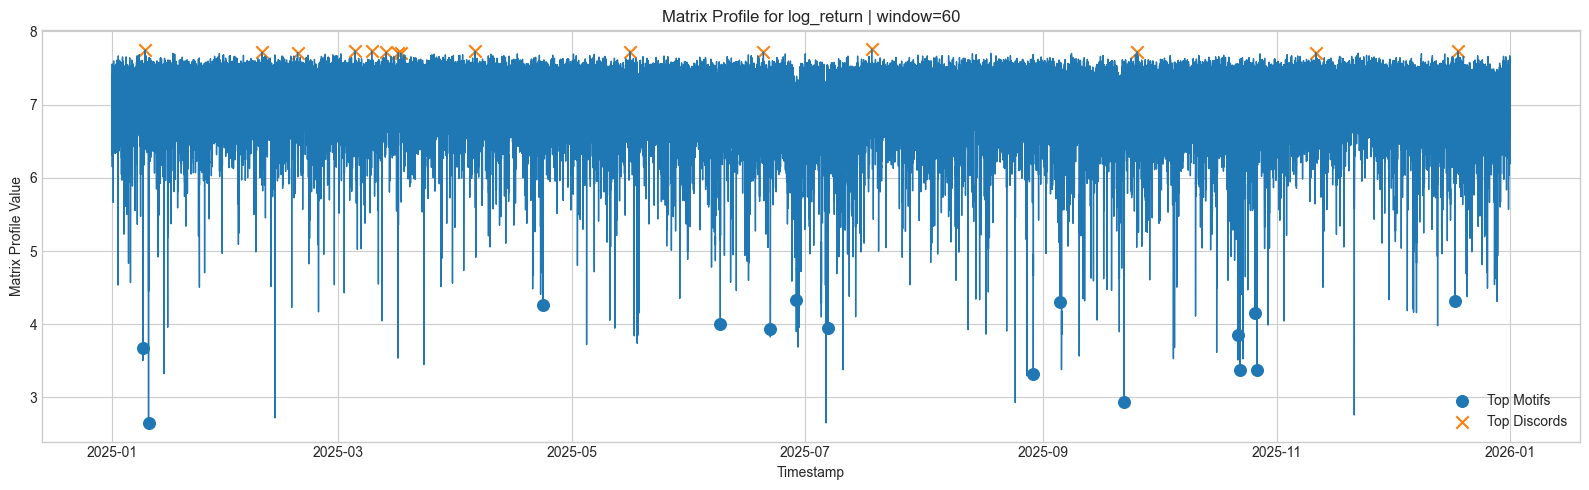

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(sample_df["timestamp"].iloc[:len(matrix_profile)], matrix_profile, linewidth=1.0)
ax.set_title(f"Matrix Profile for {candidate_column} | window={window}")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Matrix Profile Value")

if not motif_df.empty:
    ax.scatter(
        motif_df["query_time"],
        motif_df["profile_value"],
        s=70,
        marker="o",
        label="Top Motifs"
    )

if not discord_df.empty:
    ax.scatter(
        discord_df["timestamp"],
        discord_df["profile_value"],
        s=80,
        marker="x",
        label="Top Discords"
    )

ax.legend()
plt.tight_layout()
plt.show()

In [18]:
%pip install mplfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Side-by-side matrix profile + candlestick for a chosen motif

This cell plots:

left: matrix profile with highlighted motif windows

right: candlestick chart for the two matching subsequences

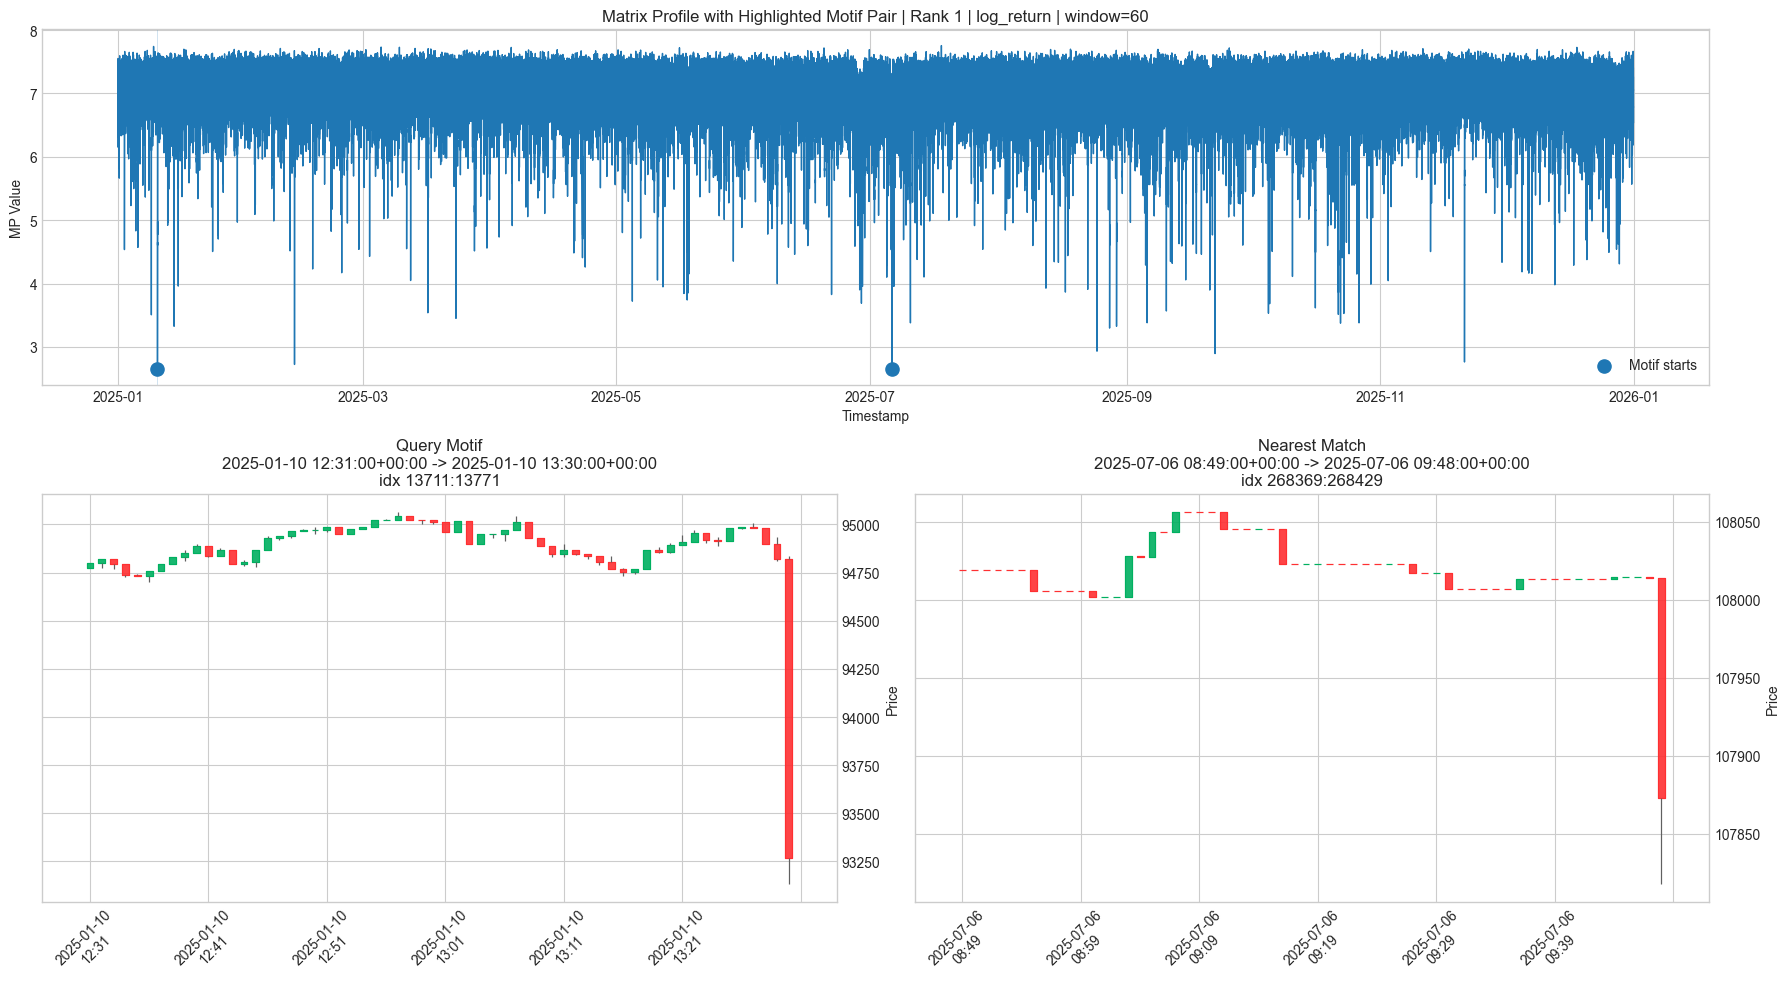

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import mplfinance as mpf

motif_rank_to_plot = 1  # change this: 1, 2, 3, ...

if motif_df.empty:
    print("No motifs available to plot.")
else:
    row = motif_df.iloc[motif_rank_to_plot - 1]

    q_idx = int(row["query_index"])
    m_idx = int(row["match_index"])

    query_slice = slice(q_idx, q_idx + window)
    match_slice = slice(m_idx, m_idx + window)

    # matrix profile series
    mp_time = sample_df["timestamp"].iloc[:len(matrix_profile)]
    mp_vals = matrix_profile

    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.15])

    # ---------- Top: matrix profile ----------
    ax_mp = fig.add_subplot(gs[0, :])
    ax_mp.plot(mp_time, mp_vals, linewidth=1.0)
    ax_mp.set_title(
        f"Matrix Profile with Highlighted Motif Pair | Rank {motif_rank_to_plot} | "
        f"{candidate_column} | window={window}"
    )
    ax_mp.set_xlabel("Timestamp")
    ax_mp.set_ylabel("MP Value")

    # highlight motif start points
    ax_mp.scatter(
        [sample_df.iloc[q_idx]["timestamp"], sample_df.iloc[m_idx]["timestamp"]],
        [matrix_profile[q_idx], matrix_profile[m_idx]],
        s=90,
        marker="o",
        label="Motif starts"
    )

    # highlight full subsequence spans
    q_start = sample_df.iloc[q_idx]["timestamp"]
    q_end = sample_df.iloc[min(q_idx + window - 1, len(sample_df) - 1)]["timestamp"]
    m_start = sample_df.iloc[m_idx]["timestamp"]
    m_end = sample_df.iloc[min(m_idx + window - 1, len(sample_df) - 1)]["timestamp"]

    ax_mp.axvspan(q_start, q_end, alpha=0.20)
    ax_mp.axvspan(m_start, m_end, alpha=0.20)
    ax_mp.legend()

    # ---------- Bottom-left: query candlestick ----------
    query_ohlc = sample_df.iloc[query_slice][["timestamp", "open", "high", "low", "close", "volume"]].copy()
    query_ohlc = query_ohlc.set_index("timestamp")

    ax_q = fig.add_subplot(gs[1, 0])
    mpf.plot(
        query_ohlc,
        type="candle",
        volume=False,
        ax=ax_q,
        style="yahoo",
        datetime_format="%Y-%m-%d\n%H:%M"
    )
    ax_q.set_title(
        f"Query Motif\n{row['query_time']} -> {row['query_end_time']}\n"
        f"idx {q_idx}:{q_idx + window}"
    )

    # ---------- Bottom-right: match candlestick ----------
    match_ohlc = sample_df.iloc[match_slice][["timestamp", "open", "high", "low", "close", "volume"]].copy()
    match_ohlc = match_ohlc.set_index("timestamp")

    ax_m = fig.add_subplot(gs[1, 1])
    mpf.plot(
        match_ohlc,
        type="candle",
        volume=False,
        ax=ax_m,
        style="yahoo",
        datetime_format="%Y-%m-%d\n%H:%M"
    )
    ax_m.set_title(
        f"Nearest Match\n{row['match_time']} -> {row['match_end_time']}\n"
        f"idx {m_idx}:{m_idx + window}"
    )

    plt.tight_layout()
    plt.show()

## Shape comparison plot for the same motif pair

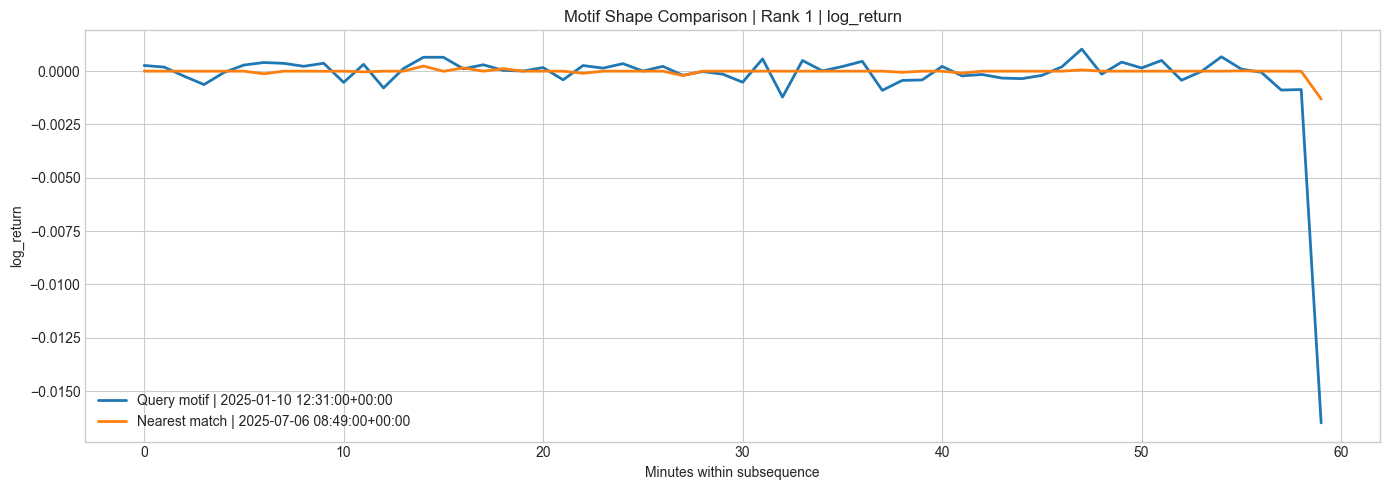

In [20]:
motif_rank_to_plot = 1  # change as needed

if motif_df.empty:
    print("No motifs available to compare.")
else:
    row = motif_df.iloc[motif_rank_to_plot - 1]

    q_idx = int(row["query_index"])
    m_idx = int(row["match_index"])

    q_signal = sample_df["signal"].iloc[q_idx:q_idx + window].to_numpy()
    m_signal = sample_df["signal"].iloc[m_idx:m_idx + window].to_numpy()

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(q_signal, linewidth=2, label=f"Query motif | {row['query_time']}")
    ax.plot(m_signal, linewidth=2, label=f"Nearest match | {row['match_time']}")
    ax.set_title(f"Motif Shape Comparison | Rank {motif_rank_to_plot} | {candidate_column}")
    ax.set_xlabel("Minutes within subsequence")
    ax.set_ylabel(candidate_column)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Same side-by-side plot but for a discord window

Discords do not have a paired neighbor in the same interpretation sense, so here we show:

top: matrix profile with discord highlighted
bottom: candlestick chart of that anomalous subsequence

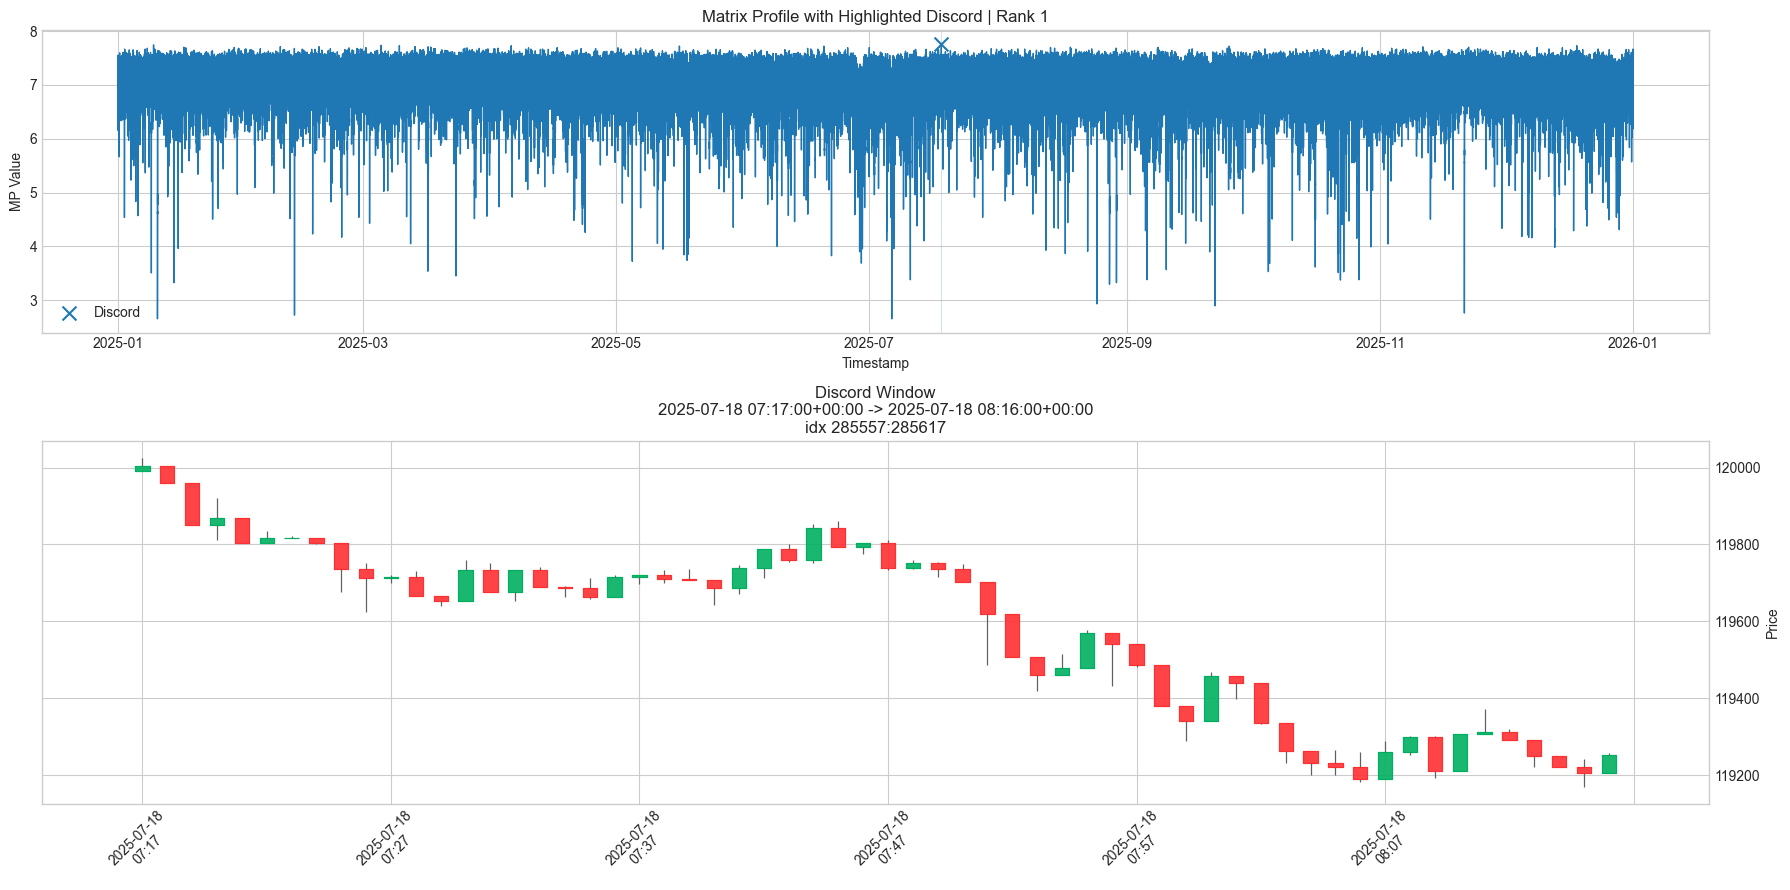

In [21]:
discord_rank_to_plot = 1  # change this

if discord_df.empty:
    print("No discords available to plot.")
else:
    row = discord_df.iloc[discord_rank_to_plot - 1]
    d_idx = int(row["index"])
    discord_slice = slice(d_idx, d_idx + window)

    fig = plt.figure(figsize=(18, 9))
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.2])

    # top: matrix profile
    ax_mp = fig.add_subplot(gs[0, 0])
    ax_mp.plot(sample_df["timestamp"].iloc[:len(matrix_profile)], matrix_profile, linewidth=1.0)
    ax_mp.scatter(row["timestamp"], row["profile_value"], s=100, marker="x", label="Discord")
    ax_mp.axvspan(row["timestamp"], row["end_time"], alpha=0.20)
    ax_mp.set_title(f"Matrix Profile with Highlighted Discord | Rank {discord_rank_to_plot}")
    ax_mp.set_xlabel("Timestamp")
    ax_mp.set_ylabel("MP Value")
    ax_mp.legend()

    # bottom: discord candlestick
    discord_ohlc = sample_df.iloc[discord_slice][["timestamp", "open", "high", "low", "close", "volume"]].copy()
    discord_ohlc = discord_ohlc.set_index("timestamp")

    ax_d = fig.add_subplot(gs[1, 0])
    mpf.plot(
        discord_ohlc,
        type="candle",
        volume=False,
        ax=ax_d,
        style="yahoo",
        datetime_format="%Y-%m-%d\n%H:%M"
    )
    ax_d.set_title(
        f"Discord Window\n{row['timestamp']} -> {row['end_time']}\n"
        f"idx {d_idx}:{d_idx + window}"
    )

    plt.tight_layout()
    plt.show()

## ETHUSDT GPU Matrix Profile Analysis (2025)

This section replicates the GPU STOMP workflow for **ETHUSDT** 1-minute data.

- **Asset**: ETHUSDT
- **Frequency**: 1-minute
- **Feature**: `log_return`
- **Window**: 60 minutes
- **Analysis Period**: Full calendar year 2025

This allows for a cross-asset comparison of motif and discord patterns against the BTC analysis performed above.

In [22]:
# ETH file resolution + loading

def resolve_eth_path(root: Path):
    candidates = [
        root / "data" / "processed" / "crypto" / "1min" / "ETHUSDT_1m_features.parquet",
        root / "data" / "processed" / "crypto" / "1min" / "ETHUSDT_1m_processed.parquet",
        root / "data" / "interim" / "crypto" / "1min" / "ETHUSDT_1m_features.parquet",
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        f"ETH processed parquet not found. Checked: {[str(c) for c in candidates]}"
    )

eth_data_path = resolve_eth_path(project_root)
df_eth = pd.read_parquet(eth_data_path)
df_eth["timestamp"] = pd.to_datetime(df_eth["timestamp"], utc=True)
df_eth = df_eth.sort_values("timestamp").reset_index(drop=True)

print(f"Resolved ETH file: {eth_data_path}")
print(f"Rows: {len(df_eth):,}")
print(f"Date range: {df_eth['timestamp'].min()} -> {df_eth['timestamp'].max()}")
print(f"Columns: {df_eth.columns.tolist()}")

Resolved ETH file: C:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis\data\processed\crypto\1min\ETHUSDT_1m_processed.parquet
Rows: 4,504,088
Date range: 2017-08-17 04:00:00+00:00 -> 2026-03-16 23:59:00+00:00
Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'log_return', 'pct_return', 'volatility_30m', 'volatility_60m', 'volatility_240m', 'realized_volatility_60m']


In [23]:
# Build ETH analysis sample

eth_candidate_column = "log_return"
eth_analysis_year = 2025
eth_window = 60

eth_year_start = pd.Timestamp(f"{eth_analysis_year}-01-01 00:00:00", tz="UTC")
eth_year_end = pd.Timestamp(f"{eth_analysis_year + 1}-01-01 00:00:00", tz="UTC")

if eth_candidate_column not in df_eth.columns:
    raise KeyError(f"Expected column '{eth_candidate_column}' not found in ETH dataframe.")

sample_df_eth = (
    df_eth[["timestamp", "open", "high", "low", "close", "volume", eth_candidate_column]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_values("timestamp")
    .reset_index(drop=True)
    .rename(columns={eth_candidate_column: "signal"})
)

sample_df_eth = sample_df_eth.loc[
    (sample_df_eth["timestamp"] >= eth_year_start) & (sample_df_eth["timestamp"] < eth_year_end)
].reset_index(drop=True).copy()

if sample_df_eth.empty:
    raise ValueError(f"No rows found for ETH in {eth_analysis_year}.")

signal_eth = sample_df_eth["signal"].to_numpy(dtype=np.float64)

# Theoretical vs Actual count
expected_count = 365 * 24 * 60  # for non-leap 2025
actual_count = len(sample_df_eth)

print(f"ETH rows used: {actual_count:,}")
print(f"ETH date range: {sample_df_eth['timestamp'].min()} -> {sample_df_eth['timestamp'].max()}")
print(f"Theoretical 1-min count (2025): {expected_count:,}")
print(f"Actual count vs theoretical: {actual_count / expected_count:.2%}")
print(f"Columns: {sample_df_eth.columns.tolist()}")

ETH rows used: 525,600
ETH date range: 2025-01-01 00:00:00+00:00 -> 2025-12-31 23:59:00+00:00
Theoretical 1-min count (2025): 525,600
Actual count vs theoretical: 100.00%
Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'signal']


In [24]:
# GPU availability summary for ETH section
from numba import cuda

print("--- ETH Analysis Config ---")
print(f"Asset: ETHUSDT")
print(f"Window: {eth_window} minutes")
print(f"CUDA available: {cuda.is_available()}")

if cuda.is_available():
    device = cuda.get_current_device()
    gpu_name_eth = device.name.decode() if isinstance(device.name, bytes) else device.name
    print(f"Active GPU: {gpu_name_eth}")
else:
    print("Backend: CPU Fallback")

--- ETH Analysis Config ---
Asset: ETHUSDT
Window: 60 minutes
CUDA available: True
Active GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [25]:
# Run matrix profile on ETH

start_eth = perf_counter()

if gpu_available:
    backend_eth = "stumpy.gpu_stump"
    mp_eth = stumpy.gpu_stump(
        signal_eth, 
        m=eth_window, 
        device_id=device_id if 'device_id' in globals() else 0
    )
else:
    backend_eth = "stumpy.stump"
    mp_eth = stumpy.stump(signal_eth, m=eth_window)

elapsed_eth = perf_counter() - start_eth

print(f"ETH Matrix Profile computed.")
print(f"Backend: {backend_eth}")
print(f"Elapsed seconds: {elapsed_eth:.2f}")

ETH Matrix Profile computed.
Backend: stumpy.gpu_stump
Elapsed seconds: 93.49


In [26]:
# Extract ETH matrix profile arrays

matrix_profile_eth = np.asarray(mp_eth[:, 0], dtype=np.float64)
nearest_neighbor_idx_eth = np.asarray(mp_eth[:, 1], dtype=np.int64)

finite_eth = np.isfinite(matrix_profile_eth)

print(f"Subsequence count: {len(matrix_profile_eth):,}")
print(f"Finite values: {finite_eth.sum():,}")
print(f"Invalid values: {(~finite_eth).sum():,}")
if finite_eth.any():
    print(f"Min MP: {np.nanmin(matrix_profile_eth):.4f}")
    print(f"Median MP: {np.nanmedian(matrix_profile_eth):.4f}")
    print(f"Max MP: {np.nanmax(matrix_profile_eth):.4f}")

Subsequence count: 525,541
Finite values: 525,541
Invalid values: 0
Min MP: 2.4389
Median MP: 7.1140
Max MP: 7.7366


In [27]:
# Build motif and discord tables for ETH

top_k_motifs_eth = 15
top_k_discords_eth = 15
exclusion_zone_eth = eth_window // 2

# Motifs extraction logic
motif_rows_eth = []
used_eth = np.zeros(len(matrix_profile_eth), dtype=bool)

for idx in np.argsort(matrix_profile_eth):
    if not np.isfinite(matrix_profile_eth[idx]):
        continue
    nn_idx = int(nearest_neighbor_idx_eth[idx])
    if nn_idx < 0 or nn_idx == idx:
        continue

    left = max(0, idx - exclusion_zone_eth)
    right = min(len(used_eth), idx + exclusion_zone_eth + 1)
    left_nn = max(0, nn_idx - exclusion_zone_eth)
    right_nn = min(len(used_eth), nn_idx + exclusion_zone_eth + 1)

    if used_eth[left:right].any() or used_eth[left_nn:right_nn].any():
        continue

    motif_rows_eth.append({
        "rank": len(motif_rows_eth) + 1,
        "query_index": int(idx),
        "match_index": int(nn_idx),
        "profile_value": float(matrix_profile_eth[idx]),
        "query_time": sample_df_eth.iloc[idx]["timestamp"],
        "match_time": sample_df_eth.iloc[nn_idx]["timestamp"],
        "query_end_time": sample_df_eth.iloc[min(idx + eth_window - 1, len(sample_df_eth) - 1)]["timestamp"],
        "match_end_time": sample_df_eth.iloc[min(nn_idx + eth_window - 1, len(sample_df_eth) - 1)]["timestamp"],
    })
    used_eth[left:right] = True
    used_eth[left_nn:right_nn] = True
    if len(motif_rows_eth) >= top_k_motifs_eth: break

motif_df_eth = pd.DataFrame(motif_rows_eth)

# Discords extraction logic
discord_rows_eth = []
used_discord_eth = np.zeros(len(matrix_profile_eth), dtype=bool)

for idx in np.argsort(-matrix_profile_eth):
    if not np.isfinite(matrix_profile_eth[idx]):
        continue
    left = max(0, idx - exclusion_zone_eth)
    right = min(len(used_discord_eth), idx + exclusion_zone_eth + 1)
    if used_discord_eth[left:right].any():
        continue

    discord_rows_eth.append({
        "rank": len(discord_rows_eth) + 1,
        "index": int(idx),
        "profile_value": float(matrix_profile_eth[idx]),
        "timestamp": sample_df_eth.iloc[idx]["timestamp"],
        "end_time": sample_df_eth.iloc[min(idx + eth_window - 1, len(sample_df_eth) - 1)]["timestamp"],
    })
    used_discord_eth[left:right] = True
    if len(discord_rows_eth) >= top_k_discords_eth: break

discord_df_eth = pd.DataFrame(discord_rows_eth)

print(f"ETH motifs found: {len(motif_df_eth)}")
print(f"ETH discords found: {len(discord_df_eth)}")

ETH motifs found: 15
ETH discords found: 15


In [28]:
# Print top ETH motifs cleanly
if not motif_df_eth.empty:
    print("TOP ETHUSDT MOTIFS (2025)")
    print("=" * 100)
    for _, row in motif_df_eth.head(10).iterrows():
        print(f"Rank {int(row['rank'])}: [{row['query_time']}] matched [{row['match_time']}] | MP={row['profile_value']:.4f}")

motif_df_eth

TOP ETHUSDT MOTIFS (2025)
Rank 1: [2025-06-21 20:25:00+00:00] matched [2025-09-22 05:00:00+00:00] | MP=2.4389
Rank 2: [2025-08-29 11:32:00+00:00] matched [2025-03-19 09:33:00+00:00] | MP=2.5861
Rank 3: [2025-04-12 11:40:00+00:00] matched [2025-03-11 12:28:00+00:00] | MP=2.7251
Rank 4: [2025-09-17 17:01:00+00:00] matched [2025-04-05 19:43:00+00:00] | MP=3.1030
Rank 5: [2025-12-28 17:19:00+00:00] matched [2025-01-10 12:34:00+00:00] | MP=3.1220
Rank 6: [2025-09-25 11:30:00+00:00] matched [2025-06-05 09:39:00+00:00] | MP=3.2836
Rank 7: [2025-07-13 20:39:00+00:00] matched [2025-03-28 03:41:00+00:00] | MP=3.3365
Rank 8: [2025-10-18 06:05:00+00:00] matched [2025-04-13 16:21:00+00:00] | MP=3.4363
Rank 9: [2025-07-10 20:20:00+00:00] matched [2025-02-21 08:19:00+00:00] | MP=3.5003
Rank 10: [2025-09-28 21:08:00+00:00] matched [2025-02-12 21:22:00+00:00] | MP=3.5288


,rank,query_index,match_index,profile_value,query_time,match_time,query_end_time,match_end_time
0,1,247465,380460,2.438902,2025-06-21 20:25:00+00:00,2025-09-22 05:00:00+00:00,2025-06-21 21:24:00+00:00,2025-09-22 05:59:00+00:00
1,2,346292,111453,2.586063,2025-08-29 11:32:00+00:00,2025-03-19 09:33:00+00:00,2025-08-29 12:31:00+00:00,2025-03-19 10:32:00+00:00
2,3,146140,100108,2.725123,2025-04-12 11:40:00+00:00,2025-03-11 12:28:00+00:00,2025-04-12 12:39:00+00:00,2025-03-11 13:27:00+00:00
3,4,373981,136543,3.102971,2025-09-17 17:01:00+00:00,2025-04-05 19:43:00+00:00,2025-09-17 18:00:00+00:00,2025-04-05 20:42:00+00:00
4,5,520879,13714,3.122049,2025-12-28 17:19:00+00:00,2025-01-10 12:34:00+00:00,2025-12-28 18:18:00+00:00,2025-01-10 13:33:00+00:00
5,6,385170,223779,3.283564,2025-09-25 11:30:00+00:00,2025-06-05 09:39:00+00:00,2025-09-25 12:29:00+00:00,2025-06-05 10:38:00+00:00
6,7,279159,124061,3.336514,2025-07-13 20:39:00+00:00,2025-03-28 03:41:00+00:00,2025-07-13 21:38:00+00:00,2025-03-28 04:40:00+00:00
7,8,417965,147861,3.436265,2025-10-18 06:05:00+00:00,2025-04-13 16:21:00+00:00,2025-10-18 07:04:00+00:00,2025-04-13 17:20:00+00:00
8,9,274820,73939,3.500333,2025-07-10 20:20:00+00:00,2025-02-21 08:19:00+00:00,2025-07-10 21:19:00+00:00,2025-02-21 09:18:00+00:00
9,10,390068,61762,3.528818,2025-09-28 21:08:00+00:00,2025-02-12 21:22:00+00:00,2025-09-28 22:07:00+00:00,2025-02-12 22:21:00+00:00


In [29]:
# Print top ETH discords cleanly
if not discord_df_eth.empty:
    print("TOP ETHUSDT DISCORDS (2025)")
    print("=" * 100)
    for _, row in discord_df_eth.head(10).iterrows():
        print(f"Rank {int(row['rank'])}: [{row['timestamp']}] | MP={row['profile_value']:.4f}")

discord_df_eth

TOP ETHUSDT DISCORDS (2025)
Rank 1: [2025-12-13 20:21:00+00:00] | MP=7.7366
Rank 2: [2025-01-11 18:19:00+00:00] | MP=7.7362
Rank 3: [2025-02-20 20:26:00+00:00] | MP=7.7311
Rank 4: [2025-01-04 04:05:00+00:00] | MP=7.7252
Rank 5: [2025-03-15 20:37:00+00:00] | MP=7.7244
Rank 6: [2025-04-24 04:42:00+00:00] | MP=7.7194
Rank 7: [2025-02-11 20:29:00+00:00] | MP=7.7142
Rank 8: [2025-03-27 11:13:00+00:00] | MP=7.7119
Rank 9: [2025-04-13 08:19:00+00:00] | MP=7.7106
Rank 10: [2025-09-17 09:33:00+00:00] | MP=7.7099


,rank,index,profile_value,timestamp,end_time
0,1,499461,7.736598,2025-12-13 20:21:00+00:00,2025-12-13 21:20:00+00:00
1,2,15499,7.736192,2025-01-11 18:19:00+00:00,2025-01-11 19:18:00+00:00
2,3,73226,7.731088,2025-02-20 20:26:00+00:00,2025-02-20 21:25:00+00:00
3,4,4565,7.725218,2025-01-04 04:05:00+00:00,2025-01-04 05:04:00+00:00
4,5,106357,7.724433,2025-03-15 20:37:00+00:00,2025-03-15 21:36:00+00:00
5,6,163002,7.719430,2025-04-24 04:42:00+00:00,2025-04-24 05:41:00+00:00
6,7,60269,7.714165,2025-02-11 20:29:00+00:00,2025-02-11 21:28:00+00:00
7,8,123073,7.711857,2025-03-27 11:13:00+00:00,2025-03-27 12:12:00+00:00
8,9,147379,7.710565,2025-04-13 08:19:00+00:00,2025-04-13 09:18:00+00:00
9,10,373533,7.709909,2025-09-17 09:33:00+00:00,2025-09-17 10:32:00+00:00


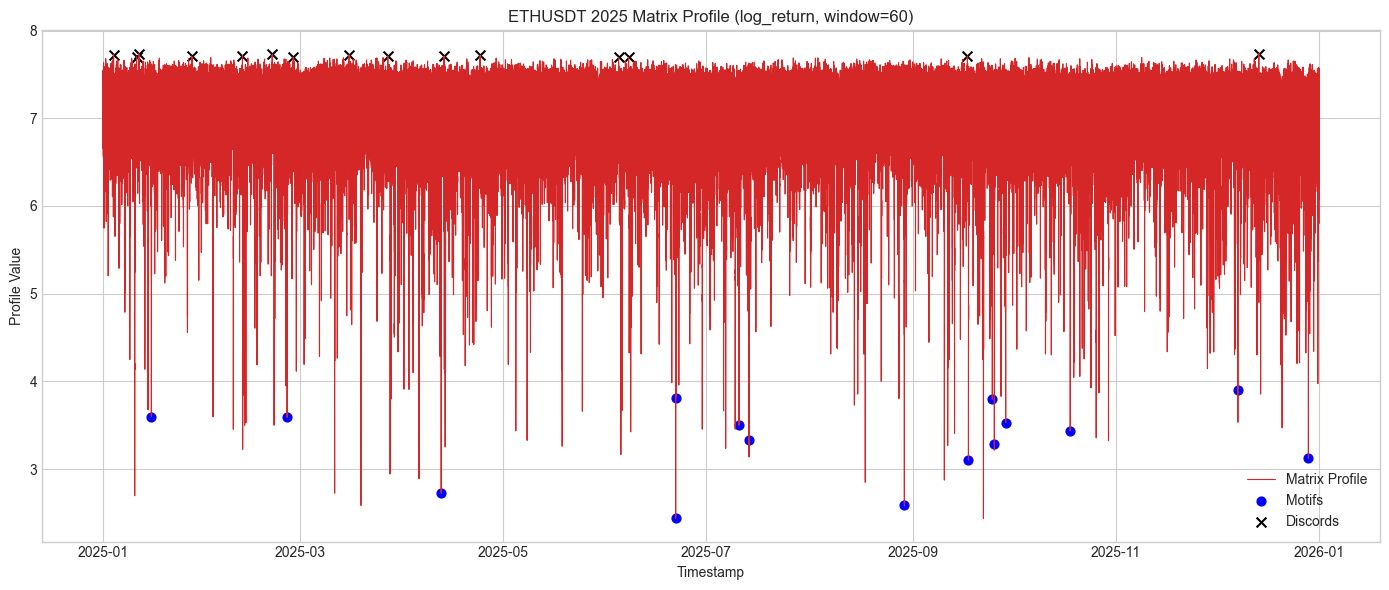

In [30]:
# Plot ETH matrix profile with motif and discord markers
plt.figure(figsize=(14, 6))
profile_ts_eth = sample_df_eth["timestamp"].iloc[:len(matrix_profile_eth)]
plt.plot(profile_ts_eth, matrix_profile_eth, label="Matrix Profile", color="tab:red", linewidth=0.8)

if not motif_df_eth.empty:
    plt.scatter(motif_df_eth["query_time"], motif_df_eth["profile_value"], c="blue", s=40, label="Motifs", marker="o")
if not discord_df_eth.empty:
    plt.scatter(discord_df_eth["timestamp"], discord_df_eth["profile_value"], c="black", s=50, label="Discords", marker="x")

plt.title(f"ETHUSDT 2025 Matrix Profile (log_return, window={eth_window})")
plt.xlabel("Timestamp")
plt.ylabel("Profile Value")
plt.legend()
plt.tight_layout()
plt.show()

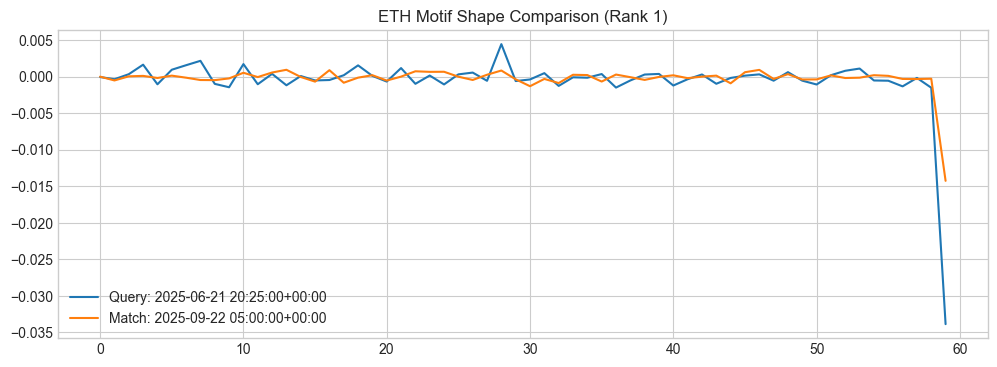

In [31]:
# Motif shape comparison for ETH
motif_rank_to_plot_eth = 1

if not motif_df_eth.empty:
    row_eth = motif_df_eth.iloc[motif_rank_to_plot_eth - 1]
    q_idx_eth = int(row_eth["query_index"])
    m_idx_eth = int(row_eth["match_index"])

    q_sig_eth = sample_df_eth["signal"].iloc[q_idx_eth : q_idx_eth + eth_window].values
    m_sig_eth = sample_df_eth["signal"].iloc[m_idx_eth : m_idx_eth + eth_window].values

    plt.figure(figsize=(12, 4))
    plt.plot(q_sig_eth, label=f"Query: {row_eth['query_time']}")
    plt.plot(m_sig_eth, label=f"Match: {row_eth['match_time']}")
    plt.title(f"ETH Motif Shape Comparison (Rank {motif_rank_to_plot_eth})")
    plt.legend()
    plt.show()

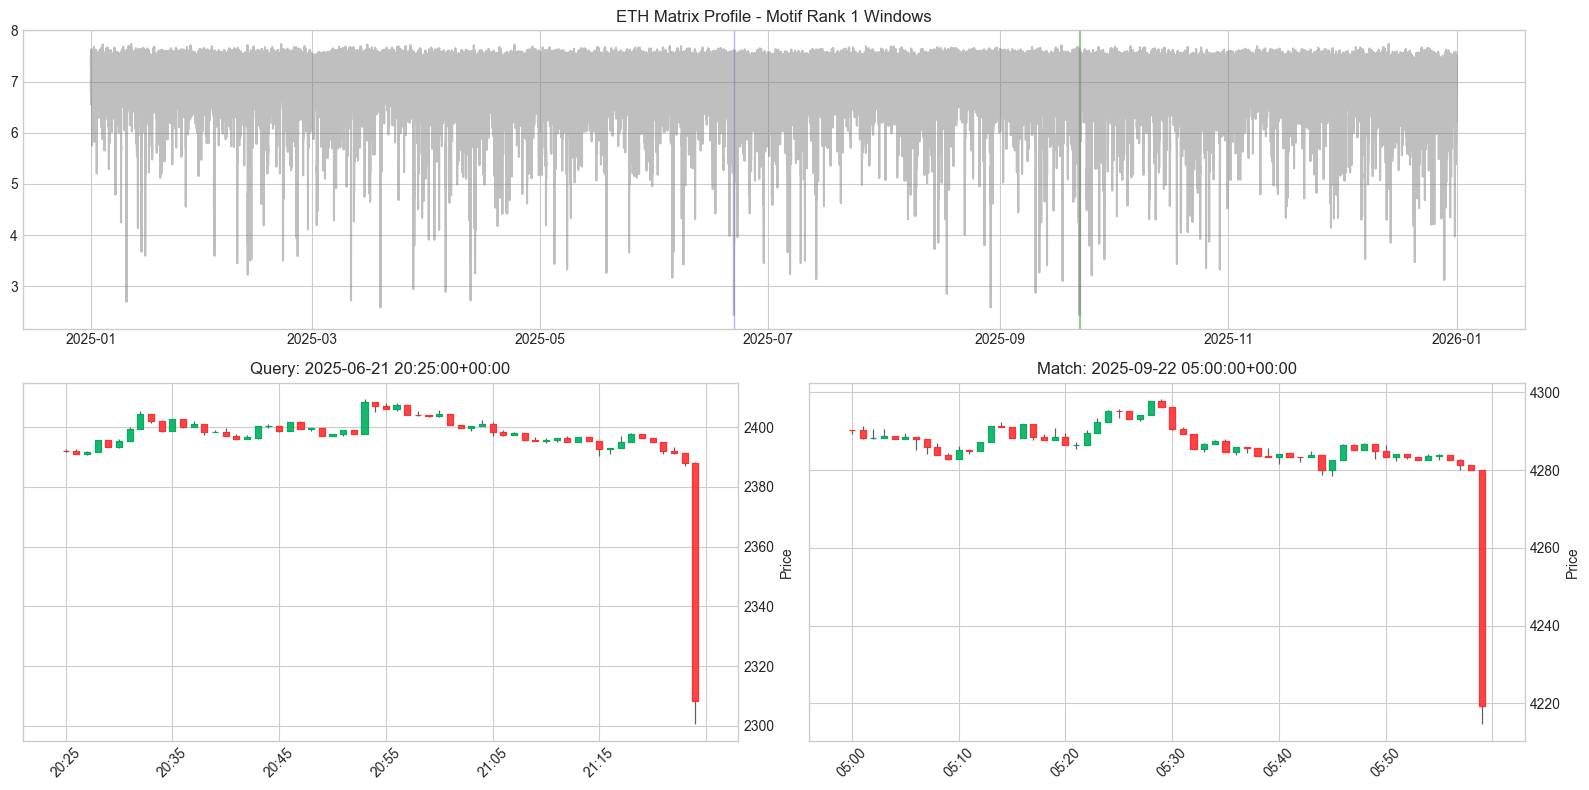

In [32]:
# Side-by-side motif candlestick inspection for ETH
import mplfinance as mpf

motif_rank_candlestick_eth = 1

if motif_df_eth.empty:
    print("No ETH motifs to display.")
else:
    row = motif_df_eth.iloc[motif_rank_candlestick_eth - 1]
    q_slice = slice(int(row["query_index"]), int(row["query_index"]) + eth_window)
    m_slice = slice(int(row["match_index"]), int(row["match_index"]) + eth_window)

    fig = plt.figure(figsize=(16, 8))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

    # Top: MP
    ax_mp = fig.add_subplot(gs[0, :])
    ax_mp.plot(profile_ts_eth, matrix_profile_eth, color="gray", alpha=0.5)
    ax_mp.axvspan(row["query_time"], row["query_end_time"], color="blue", alpha=0.3)
    ax_mp.axvspan(row["match_time"], row["match_end_time"], color="green", alpha=0.3)
    ax_mp.set_title(f"ETH Matrix Profile - Motif Rank {motif_rank_candlestick_eth} Windows")

    # Bottom Left: Query
    ax_q = fig.add_subplot(gs[1, 0])
    q_ohlc = sample_df_eth.iloc[q_slice].set_index("timestamp")[["open", "high", "low", "close", "volume"]]
    mpf.plot(q_ohlc, type="candle", ax=ax_q, style="yahoo")
    ax_q.set_title(f"Query: {row['query_time']}")

    # Bottom Right: Match
    ax_m = fig.add_subplot(gs[1, 1])
    m_ohlc = sample_df_eth.iloc[m_slice].set_index("timestamp")[["open", "high", "low", "close", "volume"]]
    mpf.plot(m_ohlc, type="candle", ax=ax_m, style="yahoo")
    ax_m.set_title(f"Match: {row['match_time']}")
    
    plt.tight_layout()
    plt.show()

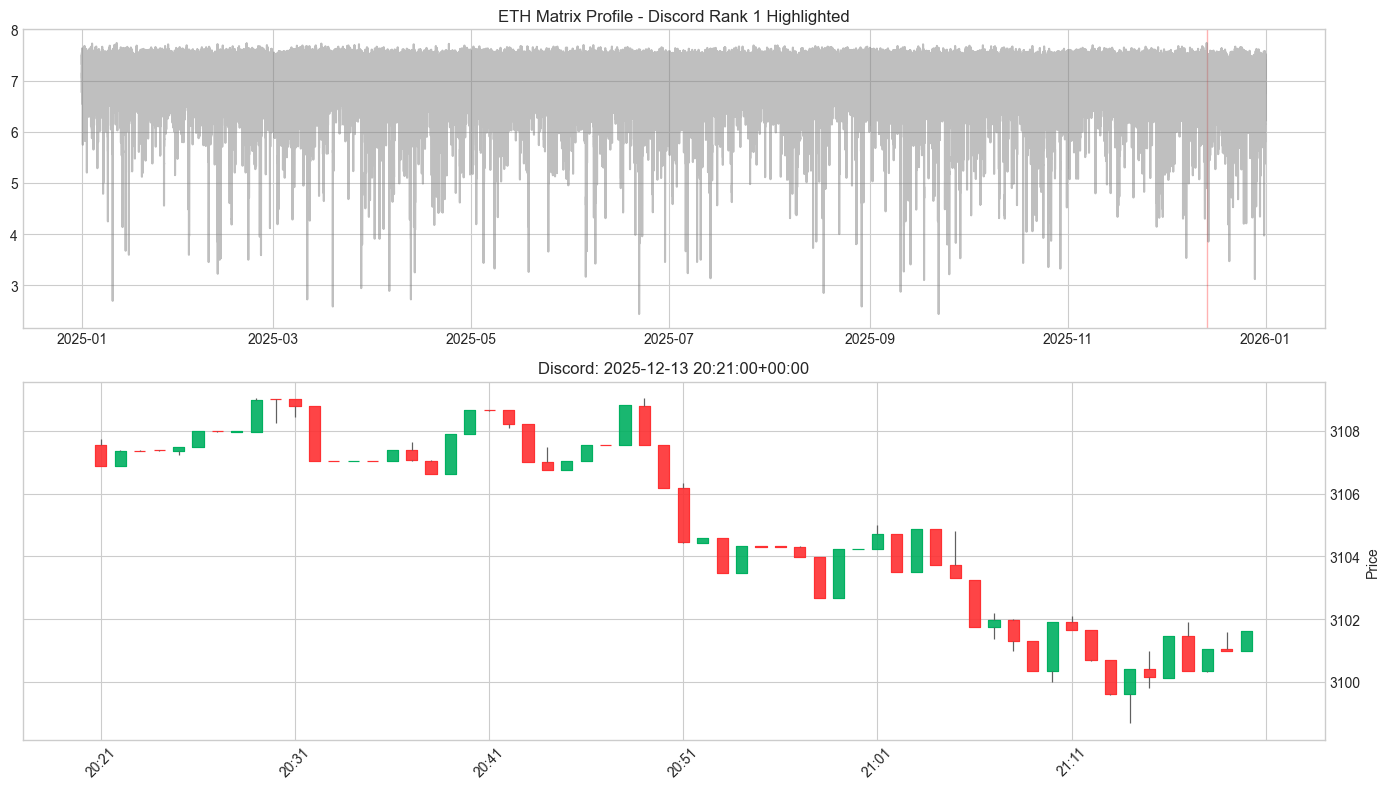

In [33]:
# Discord candlestick inspection for ETH
discord_rank_to_plot_eth = 1

if discord_df_eth.empty:
    print("No ETH discords to display.")
else:
    row = discord_df_eth.iloc[discord_rank_to_plot_eth - 1]
    d_slice = slice(int(row["index"]), int(row["index"]) + eth_window)
    
    fig = plt.figure(figsize=(14, 8))
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.2])

    ax_mp = fig.add_subplot(gs[0, 0])
    ax_mp.plot(profile_ts_eth, matrix_profile_eth, color="gray", alpha=0.5)
    ax_mp.axvspan(row["timestamp"], row["end_time"], color="red", alpha=0.3)
    ax_mp.set_title(f"ETH Matrix Profile - Discord Rank {discord_rank_to_plot_eth} Highlighted")

    ax_d = fig.add_subplot(gs[1, 0])
    d_ohlc = sample_df_eth.iloc[d_slice].set_index("timestamp")[["open", "high", "low", "close", "volume"]]
    mpf.plot(d_ohlc, type="candle", ax=ax_d, style="yahoo")
    ax_d.set_title(f"Discord: {row['timestamp']}")

    plt.tight_layout()
    plt.show()

In [34]:
# Save ETH outputs
output_dir_eth = project_root / "outputs" / "gpu_stumpy_analysis"
output_dir_eth.mkdir(parents=True, exist_ok=True)

motif_csv_eth = output_dir_eth / "motifs_ETHUSDT_log_return_window_60_2025.csv"
discord_csv_eth = output_dir_eth / "discords_ETHUSDT_log_return_window_60_2025.csv"

motif_df_eth.to_csv(motif_csv_eth, index=False)
discord_df_eth.to_csv(discord_csv_eth, index=False)

print(f"Saved ETH motifs to: {motif_csv_eth}")
print(f"Saved ETH discords to: {discord_csv_eth}")

Saved ETH motifs to: C:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis\outputs\gpu_stumpy_analysis\motifs_ETHUSDT_log_return_window_60_2025.csv
Saved ETH discords to: C:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis\outputs\gpu_stumpy_analysis\discords_ETHUSDT_log_return_window_60_2025.csv


## BTC vs ETH Motif Comparison, Overlap Analysis, and Multi-Timescale Inspection

This section compares BTCUSDT and ETHUSDT motif structure over calendar year 2025 using the same signal definition and matrix profile workflow.

It adds:
- direct BTC vs ETH comparison
- motif overlap diagnostics
- motif timing analysis
- multi-timescale motif discovery for windows 30, 60, 120, and 240
- detailed motif visualizations with timestamps

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def subseq_interval(start_idx: int, window: int):
    return (start_idx, start_idx + window - 1)

def interval_overlap_len(a_start: int, a_end: int, b_start: int, b_end: int) -> int:
    return max(0, min(a_end, b_end) - max(a_start, b_start) + 1)

def interval_overlap_ratio(start_a: int, start_b: int, window: int) -> float:
    a0, a1 = subseq_interval(start_a, window)
    b0, b1 = subseq_interval(start_b, window)
    overlap = interval_overlap_len(a0, a1, b0, b1)
    return overlap / window

def build_pairwise_overlap_table(motif_df: pd.DataFrame, window: int, label: str):
    rows = []
    if motif_df.empty or len(motif_df) < 2:
        return pd.DataFrame(columns=[
            "asset", "motif_rank_i", "motif_rank_j",
            "query_query_overlap", "query_match_overlap",
            "match_query_overlap", "match_match_overlap"
        ])

    for i in range(len(motif_df)):
        for j in range(i + 1, len(motif_df)):
            mi = motif_df.iloc[i]
            mj = motif_df.iloc[j]

            rows.append({
                "asset": label,
                "motif_rank_i": int(mi["rank"]),
                "motif_rank_j": int(mj["rank"]),
                "query_query_overlap": interval_overlap_ratio(int(mi["query_index"]), int(mj["query_index"]), window),
                "query_match_overlap": interval_overlap_ratio(int(mi["query_index"]), int(mj["match_index"]), window),
                "match_query_overlap": interval_overlap_ratio(int(mi["match_index"]), int(mj["query_index"]), window),
                "match_match_overlap": interval_overlap_ratio(int(mi["match_index"]), int(mj["match_index"]), window),
            })

    return pd.DataFrame(rows)

def add_internal_overlap_columns(motif_df: pd.DataFrame, window: int):
    motif_df = motif_df.copy()
    if motif_df.empty:
        motif_df["internal_pair_overlap_ratio"] = []
        return motif_df

    motif_df["internal_pair_overlap_ratio"] = motif_df.apply(
        lambda r: interval_overlap_ratio(int(r["query_index"]), int(r["match_index"]), window),
        axis=1
    )
    return motif_df

def zscore_subsequence(x):
    x = np.asarray(x, dtype=np.float64)
    s = x.std()
    if s == 0 or np.isnan(s):
        return np.zeros_like(x)
    return (x - x.mean()) / s

def extract_top_motifs_from_mp(matrix_profile, nearest_neighbor_idx, sample_df, window, top_k=10):
    motif_rows = []
    used = np.zeros(len(matrix_profile), dtype=bool)
    exclusion_zone = max(1, window // 2)

    for idx in np.argsort(matrix_profile):
        if not np.isfinite(matrix_profile[idx]):
            continue

        nn_idx = int(nearest_neighbor_idx[idx])
        if nn_idx < 0 or nn_idx == idx:
            continue

        left = max(0, idx - exclusion_zone)
        right = min(len(used), idx + exclusion_zone + 1)
        left_nn = max(0, nn_idx - exclusion_zone)
        right_nn = min(len(used), nn_idx + exclusion_zone + 1)

        if used[left:right].any() or used[left_nn:right_nn].any():
            continue

        motif_rows.append({
            "rank": len(motif_rows) + 1,
            "query_index": int(idx),
            "match_index": int(nn_idx),
            "profile_value": float(matrix_profile[idx]),
            "query_time": sample_df.iloc[idx]["timestamp"],
            "match_time": sample_df.iloc[nn_idx]["timestamp"],
            "query_end_time": sample_df.iloc[min(idx + window - 1, len(sample_df) - 1)]["timestamp"],
            "match_end_time": sample_df.iloc[min(nn_idx + window - 1, len(sample_df) - 1)]["timestamp"],
        })

        used[left:right] = True
        used[left_nn:right_nn] = True

        if len(motif_rows) >= top_k:
            break

    return pd.DataFrame(motif_rows)

def run_mp_for_signal(signal_array, window, gpu_available=True, device_id=0):
    if gpu_available:
        mp_local = stumpy.gpu_stump(signal_array, m=window, device_id=device_id)
        backend_local = "gpu_stump"
    else:
        mp_local = stumpy.stump(signal_array, m=window)
        backend_local = "stump"

    matrix_profile_local = np.asarray(mp_local[:, 0], dtype=np.float64)
    nearest_neighbor_local = np.asarray(mp_local[:, 1], dtype=np.int64)
    return matrix_profile_local, nearest_neighbor_local, backend_local

Clean BTC and ETH motif tables with overlap columns

In [36]:
motif_df_btc_cmp = add_internal_overlap_columns(motif_df.copy(), window)
motif_df_eth_cmp = add_internal_overlap_columns(motif_df_eth.copy(), eth_window)

display_cols = [
    "rank", "query_time", "query_end_time",
    "match_time", "match_end_time",
    "profile_value", "internal_pair_overlap_ratio"
]

print("BTC motifs with internal pair overlap")
display(motif_df_btc_cmp[display_cols].head(10))

print("ETH motifs with internal pair overlap")
display(motif_df_eth_cmp[display_cols].head(10))

BTC motifs with internal pair overlap


,rank,query_time,query_end_time,match_time,match_end_time,profile_value,internal_pair_overlap_ratio
0,1,2025-01-10 12:31:00+00:00,2025-01-10 13:30:00+00:00,2025-07-06 08:49:00+00:00,2025-07-06 09:48:00+00:00,2.653183,0.0
1,2,2025-09-22 05:03:00+00:00,2025-09-22 06:02:00+00:00,2025-08-24 18:38:00+00:00,2025-08-24 19:37:00+00:00,2.931639,0.0
2,3,2025-08-29 11:31:00+00:00,2025-08-29 12:30:00+00:00,2025-01-14 12:31:00+00:00,2025-01-14 13:30:00+00:00,3.324551,0.0
3,4,2025-10-22 10:04:00+00:00,2025-10-22 11:03:00+00:00,2025-11-21 06:34:00+00:00,2025-11-21 07:33:00+00:00,3.373826,0.0
4,5,2025-10-26 21:04:00+00:00,2025-10-26 22:03:00+00:00,2025-07-10 20:18:00+00:00,2025-07-10 21:17:00+00:00,3.378580,0.0
5,6,2025-01-09 01:11:00+00:00,2025-01-09 02:10:00+00:00,2025-10-05 08:34:00+00:00,2025-10-05 09:33:00+00:00,3.680803,0.0
6,7,2025-10-21 22:31:00+00:00,2025-10-21 23:30:00+00:00,2025-09-05 21:16:00+00:00,2025-09-05 22:15:00+00:00,3.857683,0.0
7,8,2025-06-21 20:25:00+00:00,2025-06-21 21:24:00+00:00,2025-08-27 19:22:00+00:00,2025-08-27 20:21:00+00:00,3.930583,0.0
8,9,2025-07-06 20:32:00+00:00,2025-07-06 21:31:00+00:00,2025-06-29 07:05:00+00:00,2025-06-29 08:04:00+00:00,3.954404,0.0
9,10,2025-06-08 18:48:00+00:00,2025-06-08 19:47:00+00:00,2025-05-04 21:09:00+00:00,2025-05-04 22:08:00+00:00,3.997043,0.0


ETH motifs with internal pair overlap


,rank,query_time,query_end_time,match_time,match_end_time,profile_value,internal_pair_overlap_ratio
0,1,2025-06-21 20:25:00+00:00,2025-06-21 21:24:00+00:00,2025-09-22 05:00:00+00:00,2025-09-22 05:59:00+00:00,2.438902,0.0
1,2,2025-08-29 11:32:00+00:00,2025-08-29 12:31:00+00:00,2025-03-19 09:33:00+00:00,2025-03-19 10:32:00+00:00,2.586063,0.0
2,3,2025-04-12 11:40:00+00:00,2025-04-12 12:39:00+00:00,2025-03-11 12:28:00+00:00,2025-03-11 13:27:00+00:00,2.725123,0.0
3,4,2025-09-17 17:01:00+00:00,2025-09-17 18:00:00+00:00,2025-04-05 19:43:00+00:00,2025-04-05 20:42:00+00:00,3.102971,0.0
4,5,2025-12-28 17:19:00+00:00,2025-12-28 18:18:00+00:00,2025-01-10 12:34:00+00:00,2025-01-10 13:33:00+00:00,3.122049,0.0
5,6,2025-09-25 11:30:00+00:00,2025-09-25 12:29:00+00:00,2025-06-05 09:39:00+00:00,2025-06-05 10:38:00+00:00,3.283564,0.0
6,7,2025-07-13 20:39:00+00:00,2025-07-13 21:38:00+00:00,2025-03-28 03:41:00+00:00,2025-03-28 04:40:00+00:00,3.336514,0.0
7,8,2025-10-18 06:05:00+00:00,2025-10-18 07:04:00+00:00,2025-04-13 16:21:00+00:00,2025-04-13 17:20:00+00:00,3.436265,0.0
8,9,2025-07-10 20:20:00+00:00,2025-07-10 21:19:00+00:00,2025-02-21 08:19:00+00:00,2025-02-21 09:18:00+00:00,3.500333,0.0
9,10,2025-09-28 21:08:00+00:00,2025-09-28 22:07:00+00:00,2025-02-12 21:22:00+00:00,2025-02-12 22:21:00+00:00,3.528818,0.0


Pairwise overlap analysis across selected motifs

In [37]:
btc_pairwise_overlap = build_pairwise_overlap_table(motif_df_btc_cmp, window, "BTC")
eth_pairwise_overlap = build_pairwise_overlap_table(motif_df_eth_cmp, eth_window, "ETH")

print("BTC pairwise motif overlap summary")
if not btc_pairwise_overlap.empty:
    display(btc_pairwise_overlap.describe())
else:
    print("Not enough BTC motifs for pairwise overlap analysis.")

print("ETH pairwise motif overlap summary")
if not eth_pairwise_overlap.empty:
    display(eth_pairwise_overlap.describe())
else:
    print("Not enough ETH motifs for pairwise overlap analysis.")

BTC pairwise motif overlap summary


,motif_rank_i,motif_rank_j,query_query_overlap,query_match_overlap,match_query_overlap,match_match_overlap
count,105.000000,105.000000,105.0,105.0,105.0,105.0
mean,5.333333,10.666667,0.0,0.0,0.0,0.0
std,3.415650,3.415650,0.0,0.0,0.0,0.0
min,1.000000,2.000000,0.0,0.0,0.0,0.0
25%,2.000000,8.000000,0.0,0.0,0.0,0.0
50%,5.000000,11.000000,0.0,0.0,0.0,0.0
75%,8.000000,14.000000,0.0,0.0,0.0,0.0
max,14.000000,15.000000,0.0,0.0,0.0,0.0


ETH pairwise motif overlap summary


,motif_rank_i,motif_rank_j,query_query_overlap,query_match_overlap,match_query_overlap,match_match_overlap
count,105.000000,105.000000,105.0,105.0,105.0,105.0
mean,5.333333,10.666667,0.0,0.0,0.0,0.0
std,3.415650,3.415650,0.0,0.0,0.0,0.0
min,1.000000,2.000000,0.0,0.0,0.0,0.0
25%,2.000000,8.000000,0.0,0.0,0.0,0.0
50%,5.000000,11.000000,0.0,0.0,0.0,0.0
75%,8.000000,14.000000,0.0,0.0,0.0,0.0
max,14.000000,15.000000,0.0,0.0,0.0,0.0


Side-by-side BTC vs ETH matrix profile comparison

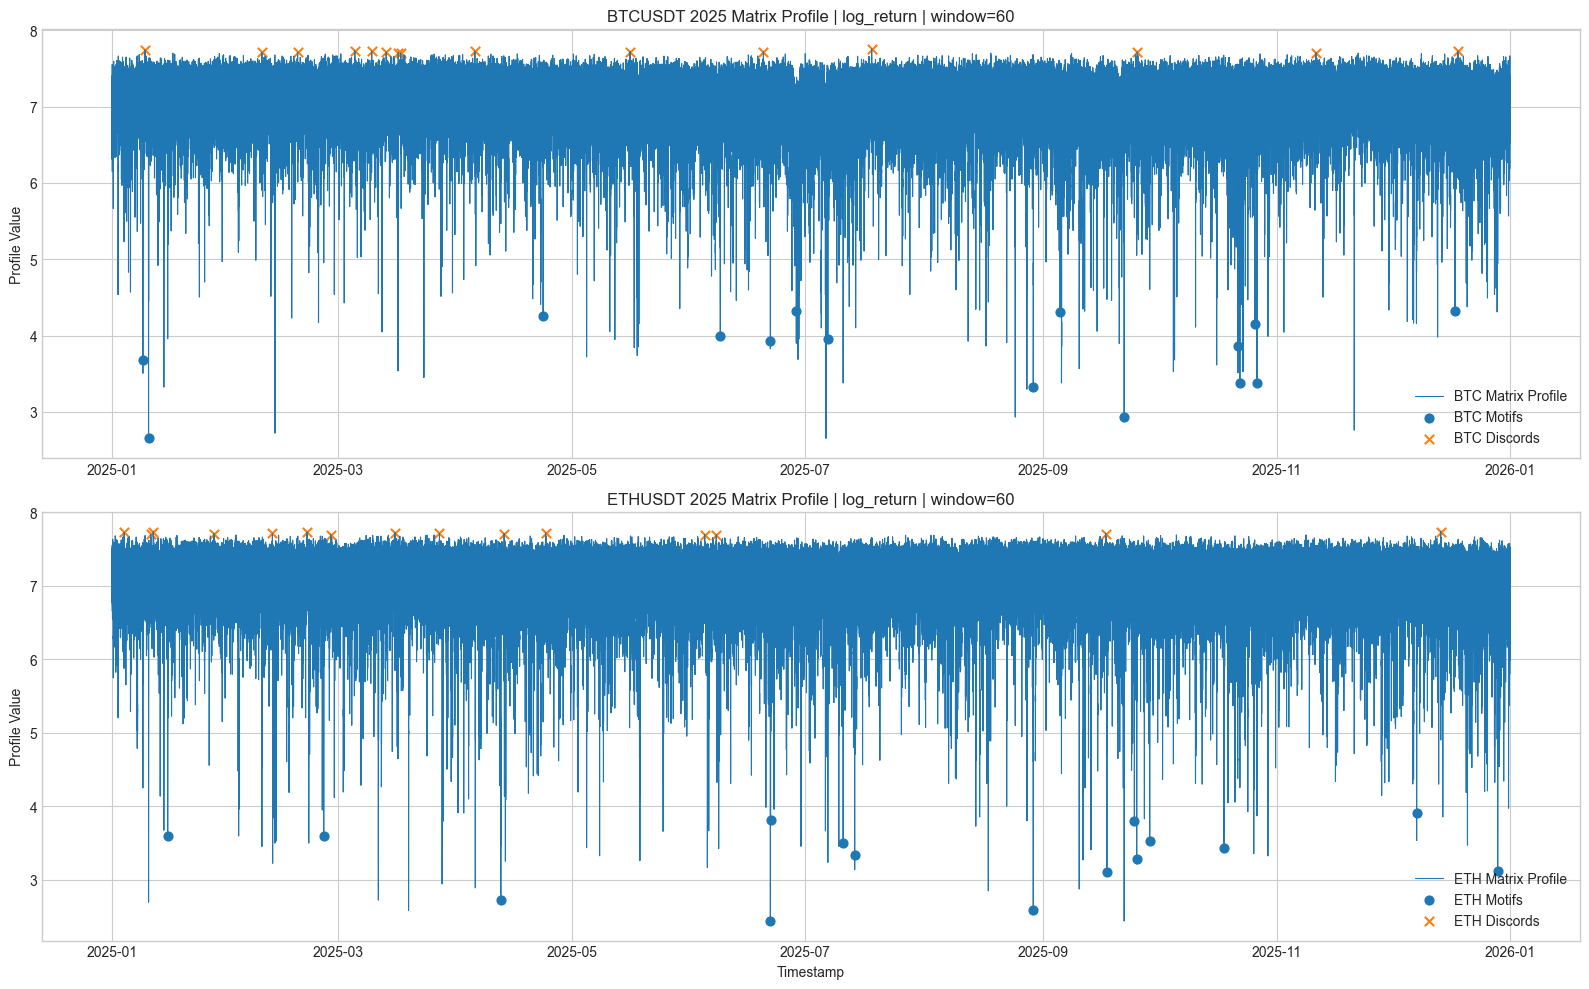

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)

# BTC
btc_ts = sample_df["timestamp"].iloc[:len(matrix_profile)]
axes[0].plot(btc_ts, matrix_profile, linewidth=0.8, label="BTC Matrix Profile")
if not motif_df.empty:
    axes[0].scatter(motif_df["query_time"], motif_df["profile_value"], s=40, marker="o", label="BTC Motifs")
if not discord_df.empty:
    axes[0].scatter(discord_df["timestamp"], discord_df["profile_value"], s=45, marker="x", label="BTC Discords")
axes[0].set_title(f"BTCUSDT 2025 Matrix Profile | {candidate_column} | window={window}")
axes[0].set_ylabel("Profile Value")
axes[0].legend()

# ETH
eth_ts = sample_df_eth["timestamp"].iloc[:len(matrix_profile_eth)]
axes[1].plot(eth_ts, matrix_profile_eth, linewidth=0.8, label="ETH Matrix Profile")
if not motif_df_eth.empty:
    axes[1].scatter(motif_df_eth["query_time"], motif_df_eth["profile_value"], s=40, marker="o", label="ETH Motifs")
if not discord_df_eth.empty:
    axes[1].scatter(discord_df_eth["timestamp"], discord_df_eth["profile_value"], s=45, marker="x", label="ETH Discords")
axes[1].set_title(f"ETHUSDT 2025 Matrix Profile | {eth_candidate_column} | window={eth_window}")
axes[1].set_ylabel("Profile Value")
axes[1].set_xlabel("Timestamp")
axes[1].legend()

plt.tight_layout()
plt.show()

BTC vs ETH motif summary table

In [39]:
summary_rows = []

if not motif_df.empty:
    summary_rows.append({
        "asset": "BTC",
        "window": window,
        "num_motifs": len(motif_df),
        "num_discords": len(discord_df),
        "best_motif_mp_value": motif_df["profile_value"].min(),
        "median_motif_mp_value": motif_df["profile_value"].median(),
        "worst_discord_mp_value": discord_df["profile_value"].max() if not discord_df.empty else np.nan,
        "first_motif_time": motif_df["query_time"].min(),
        "last_motif_time": motif_df["query_time"].max(),
    })

if not motif_df_eth.empty:
    summary_rows.append({
        "asset": "ETH",
        "window": eth_window,
        "num_motifs": len(motif_df_eth),
        "num_discords": len(discord_df_eth),
        "best_motif_mp_value": motif_df_eth["profile_value"].min(),
        "median_motif_mp_value": motif_df_eth["profile_value"].median(),
        "worst_discord_mp_value": discord_df_eth["profile_value"].max() if not discord_df_eth.empty else np.nan,
        "first_motif_time": motif_df_eth["query_time"].min(),
        "last_motif_time": motif_df_eth["query_time"].max(),
    })

comparison_summary_df = pd.DataFrame(summary_rows)
comparison_summary_df

,asset,window,num_motifs,num_discords,best_motif_mp_value,median_motif_mp_value,worst_discord_mp_value,first_motif_time,last_motif_time
0,BTC,60,15,15,2.653183,3.930583,7.756587,2025-01-09 01:11:00+00:00,2025-12-17 13:55:00+00:00
1,ETH,60,15,15,2.438902,3.436265,7.736598,2025-01-15 12:32:00+00:00,2025-12-28 17:19:00+00:00


Normalized shape comparison for BTC vs ETH top motif

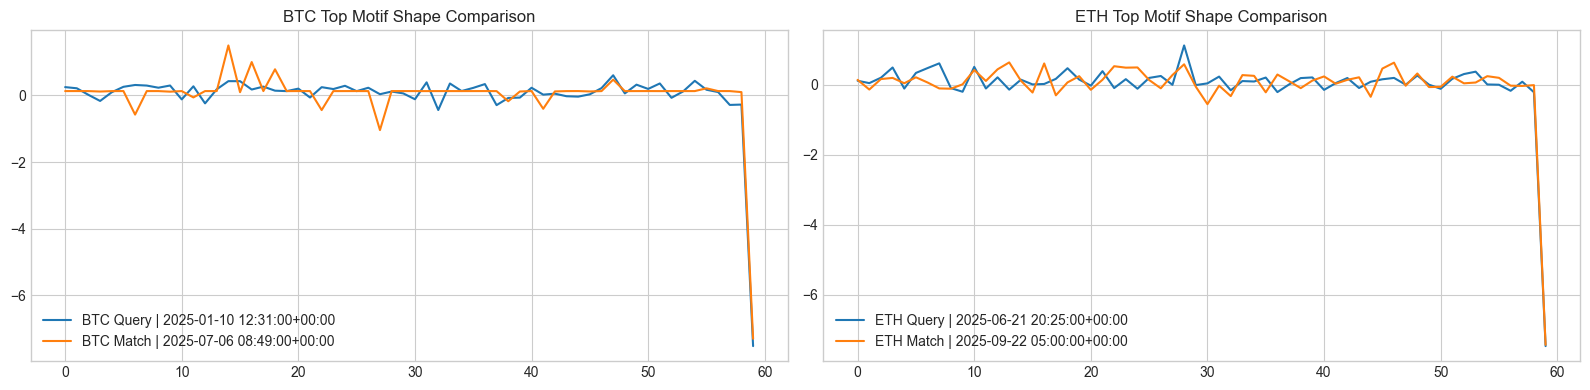

In [40]:
btc_rank = 1
eth_rank = 1

if motif_df.empty or motif_df_eth.empty:
    print("Need at least one BTC motif and one ETH motif.")
else:
    row_btc = motif_df.iloc[btc_rank - 1]
    row_eth = motif_df_eth.iloc[eth_rank - 1]

    btc_q = sample_df["signal"].iloc[int(row_btc["query_index"]): int(row_btc["query_index"]) + window].to_numpy()
    btc_m = sample_df["signal"].iloc[int(row_btc["match_index"]): int(row_btc["match_index"]) + window].to_numpy()

    eth_q = sample_df_eth["signal"].iloc[int(row_eth["query_index"]): int(row_eth["query_index"]) + eth_window].to_numpy()
    eth_m = sample_df_eth["signal"].iloc[int(row_eth["match_index"]): int(row_eth["match_index"]) + eth_window].to_numpy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    axes[0].plot(zscore_subsequence(btc_q), label=f"BTC Query | {row_btc['query_time']}")
    axes[0].plot(zscore_subsequence(btc_m), label=f"BTC Match | {row_btc['match_time']}")
    axes[0].set_title("BTC Top Motif Shape Comparison")
    axes[0].legend()

    axes[1].plot(zscore_subsequence(eth_q), label=f"ETH Query | {row_eth['query_time']}")
    axes[1].plot(zscore_subsequence(eth_m), label=f"ETH Match | {row_eth['match_time']}")
    axes[1].set_title("ETH Top Motif Shape Comparison")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Multi-timescale motif analysis

In [42]:
multi_windows = [30, 60, 120, 240]
multi_scale_rows = []

signal_btc = sample_df["signal"].to_numpy(dtype=np.float64)
signal_eth = sample_df_eth["signal"].to_numpy(dtype=np.float64)

for w in multi_windows:
    if len(signal_btc) > w:
        mp_btc_w, nn_btc_w, backend_btc_w = run_mp_for_signal(
            signal_btc, w, gpu_available=gpu_available, device_id=device_id if "device_id" in globals() else 0
        )
        motifs_btc_w = extract_top_motifs_from_mp(mp_btc_w, nn_btc_w, sample_df, w, top_k=10)

        multi_scale_rows.append({
            "asset": "BTC",
            "window": w,
            "backend": backend_btc_w,
            "num_motifs": len(motifs_btc_w),
            "best_motif_mp": motifs_btc_w["profile_value"].min() if not motifs_btc_w.empty else np.nan,
            "median_motif_mp": motifs_btc_w["profile_value"].median() if not motifs_btc_w.empty else np.nan,
            "top_motif_time": motifs_btc_w.iloc[0]["query_time"] if not motifs_btc_w.empty else pd.NaT,
        })

    if len(signal_eth) > w:
        mp_eth_w, nn_eth_w, backend_eth_w = run_mp_for_signal(
            signal_eth, w, gpu_available=gpu_available, device_id=device_id if "device_id" in globals() else 0
        )
        motifs_eth_w = extract_top_motifs_from_mp(mp_eth_w, nn_eth_w, sample_df_eth, w, top_k=10)

        multi_scale_rows.append({
            "asset": "ETH",
            "window": w,
            "backend": backend_eth_w,
            "num_motifs": len(motifs_eth_w),
            "best_motif_mp": motifs_eth_w["profile_value"].min() if not motifs_eth_w.empty else np.nan,
            "median_motif_mp": motifs_eth_w["profile_value"].median() if not motifs_eth_w.empty else np.nan,
            "top_motif_time": motifs_eth_w.iloc[0]["query_time"] if not motifs_eth_w.empty else pd.NaT,
        })

multi_scale_df = pd.DataFrame(multi_scale_rows)
multi_scale_df.sort_values(["asset", "window"])

,asset,window,backend,num_motifs,best_motif_mp,median_motif_mp,top_motif_time
0,BTC,30,gpu_stump,10,0.132429,1.565599,2025-09-27 20:55:00+00:00
2,BTC,60,gpu_stump,10,2.653183,3.529691,2025-01-10 12:31:00+00:00
4,BTC,120,gpu_stump,10,4.838135,6.822489,2025-01-10 11:31:00+00:00
6,BTC,240,gpu_stump,10,8.246652,12.359017,2025-01-10 09:31:00+00:00
1,ETH,30,gpu_stump,10,1.061407,1.539911,2025-06-21 20:55:00+00:00
3,ETH,60,gpu_stump,10,2.438902,3.202807,2025-06-21 20:25:00+00:00
5,ETH,120,gpu_stump,10,4.552413,6.214791,2025-09-22 04:00:00+00:00
7,ETH,240,gpu_stump,10,8.742916,10.880766,2025-06-21 17:26:00+00:00


Multi-timescale chart

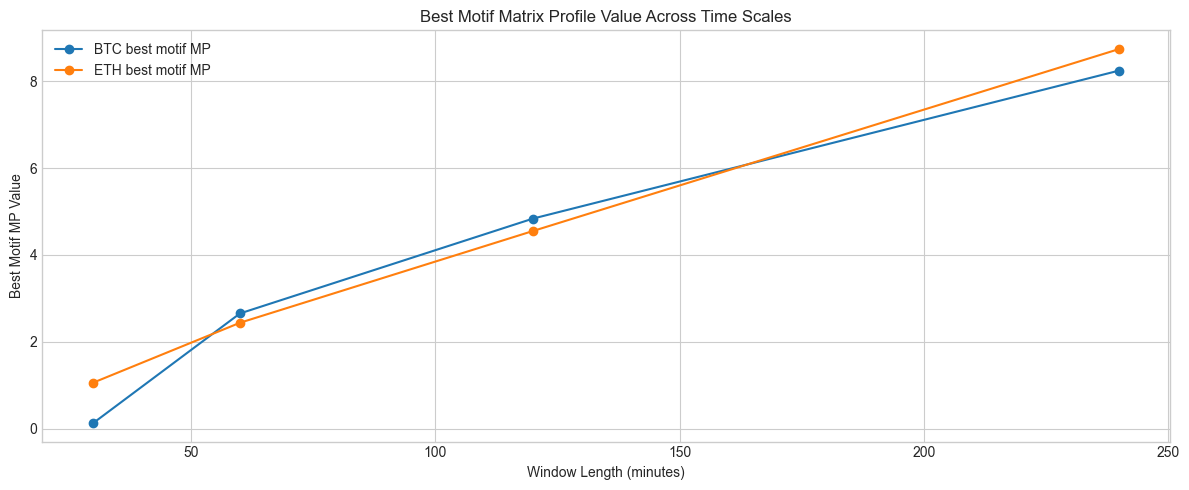

In [43]:
if multi_scale_df.empty:
    print("No multi-timescale results available.")
else:
    fig, ax = plt.subplots(figsize=(12, 5))

    for asset in ["BTC", "ETH"]:
        sub = multi_scale_df[multi_scale_df["asset"] == asset].sort_values("window")
        if not sub.empty:
            ax.plot(sub["window"], sub["best_motif_mp"], marker="o", label=f"{asset} best motif MP")

    ax.set_title("Best Motif Matrix Profile Value Across Time Scales")
    ax.set_xlabel("Window Length (minutes)")
    ax.set_ylabel("Best Motif MP Value")
    ax.legend()
    plt.tight_layout()
    plt.show()

Monthly motif timing concentration

In [44]:
def monthly_motif_counts(motif_df_local, label):
    if motif_df_local.empty:
        return pd.DataFrame(columns=["month", "count", "asset"])
    out = motif_df_local.copy()
    out["month"] = pd.to_datetime(out["query_time"]).dt.to_period("M").astype(str)
    out = out.groupby("month").size().reset_index(name="count")
    out["asset"] = label
    return out

btc_monthly = monthly_motif_counts(motif_df, "BTC")
eth_monthly = monthly_motif_counts(motif_df_eth, "ETH")
monthly_counts_df = pd.concat([btc_monthly, eth_monthly], ignore_index=True)

monthly_counts_df

C:\Users\learn\AppData\Local\Temp\ipykernel_18888\2904362449.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  out["month"] = pd.to_datetime(out["query_time"]).dt.to_period("M").astype(str)
C:\Users\learn\AppData\Local\Temp\ipykernel_18888\2904362449.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  out["month"] = pd.to_datetime(out["query_time"]).dt.to_period("M").astype(str)


,month,count,asset
0,2025-01,2,BTC
1,2025-04,1,BTC
2,2025-06,3,BTC
3,2025-07,1,BTC
4,2025-08,1,BTC
5,2025-09,2,BTC
6,2025-10,4,BTC
7,2025-12,1,BTC
8,2025-01,1,ETH
9,2025-02,1,ETH


Monthly motif count plot

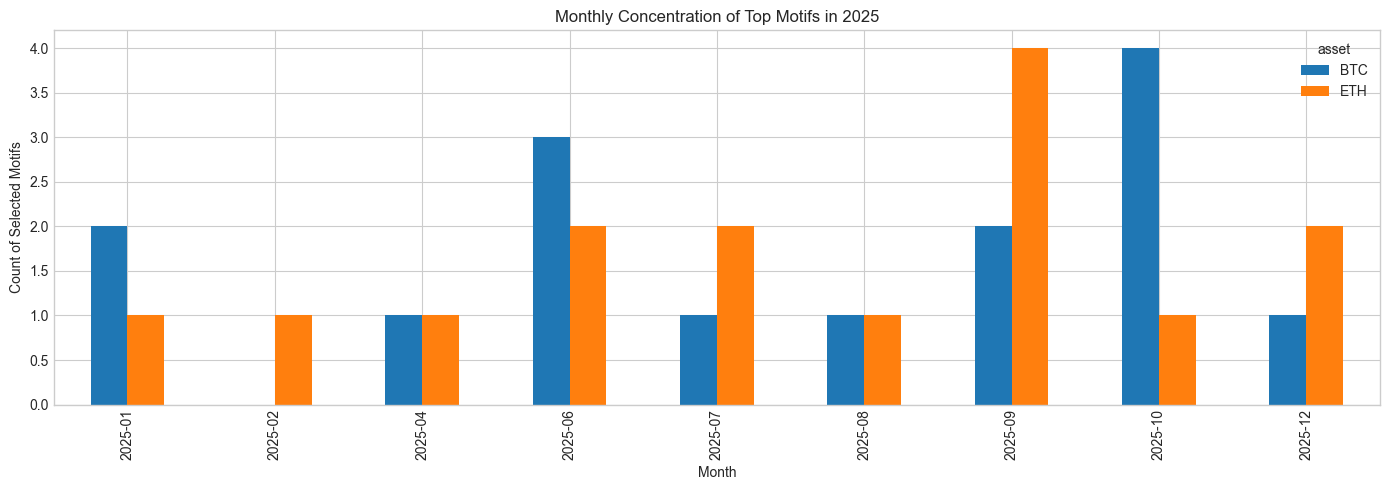

In [45]:
if monthly_counts_df.empty:
    print("No motif timing counts available.")
else:
    pivot_monthly = monthly_counts_df.pivot(index="month", columns="asset", values="count").fillna(0)
    pivot_monthly.plot(kind="bar", figsize=(14, 5))
    plt.title("Monthly Concentration of Top Motifs in 2025")
    plt.xlabel("Month")
    plt.ylabel("Count of Selected Motifs")
    plt.tight_layout()
    plt.show()

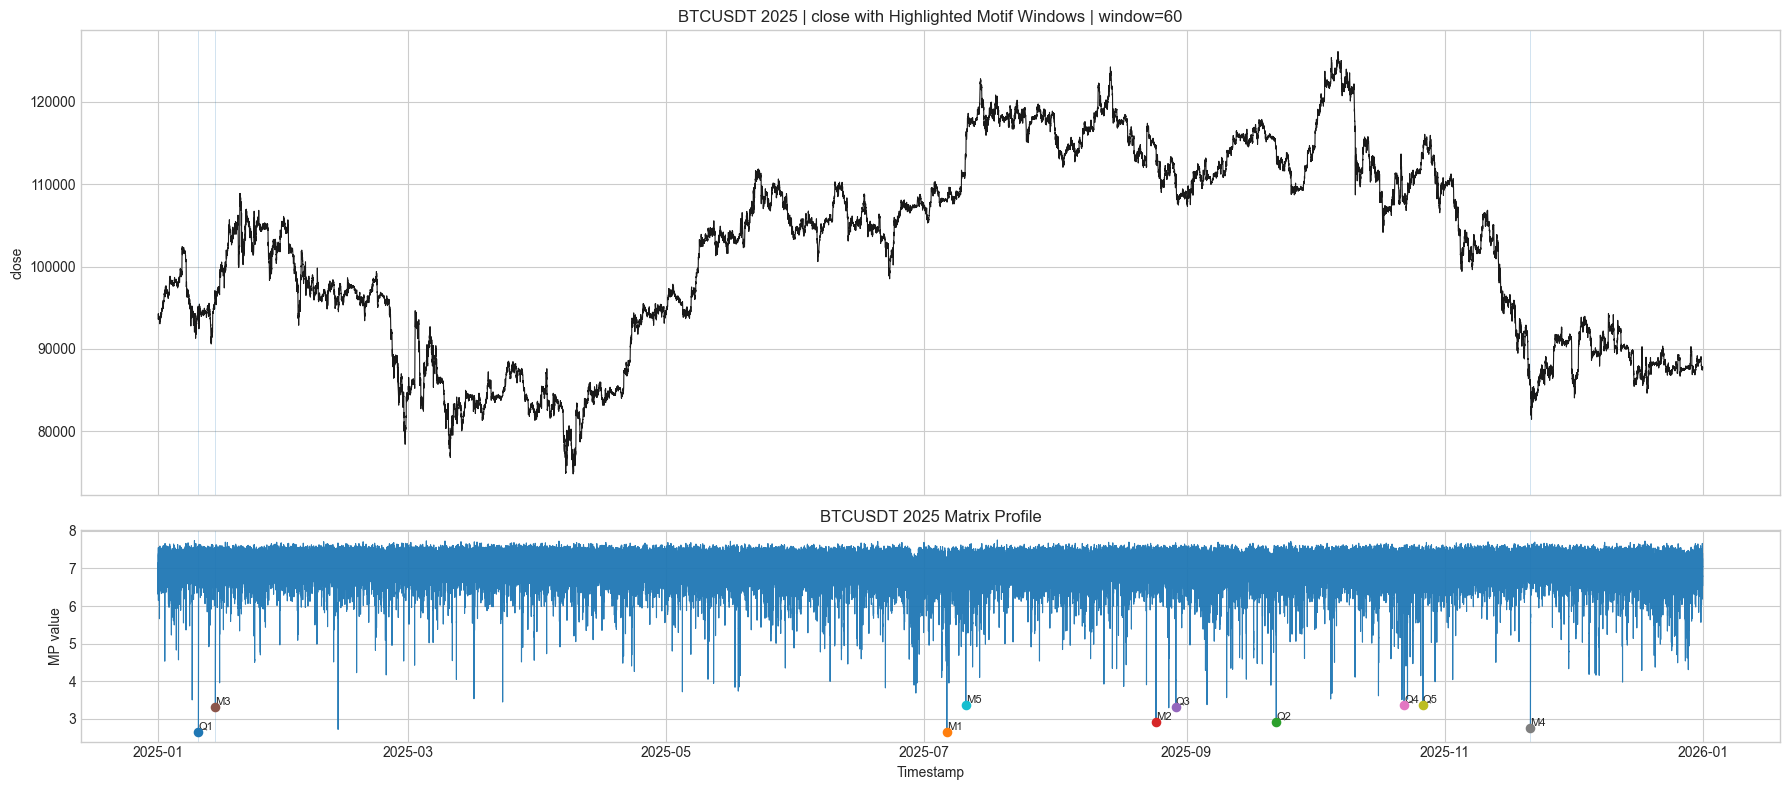

,rank,query_time,match_time,profile_value
0,1,2025-01-10 12:31:00+00:00,2025-07-06 08:49:00+00:00,2.653183
1,2,2025-09-22 05:03:00+00:00,2025-08-24 18:38:00+00:00,2.931639
2,3,2025-08-29 11:31:00+00:00,2025-01-14 12:31:00+00:00,3.324551
3,4,2025-10-22 10:04:00+00:00,2025-11-21 06:34:00+00:00,3.373826
4,5,2025-10-26 21:04:00+00:00,2025-07-10 20:18:00+00:00,3.378580


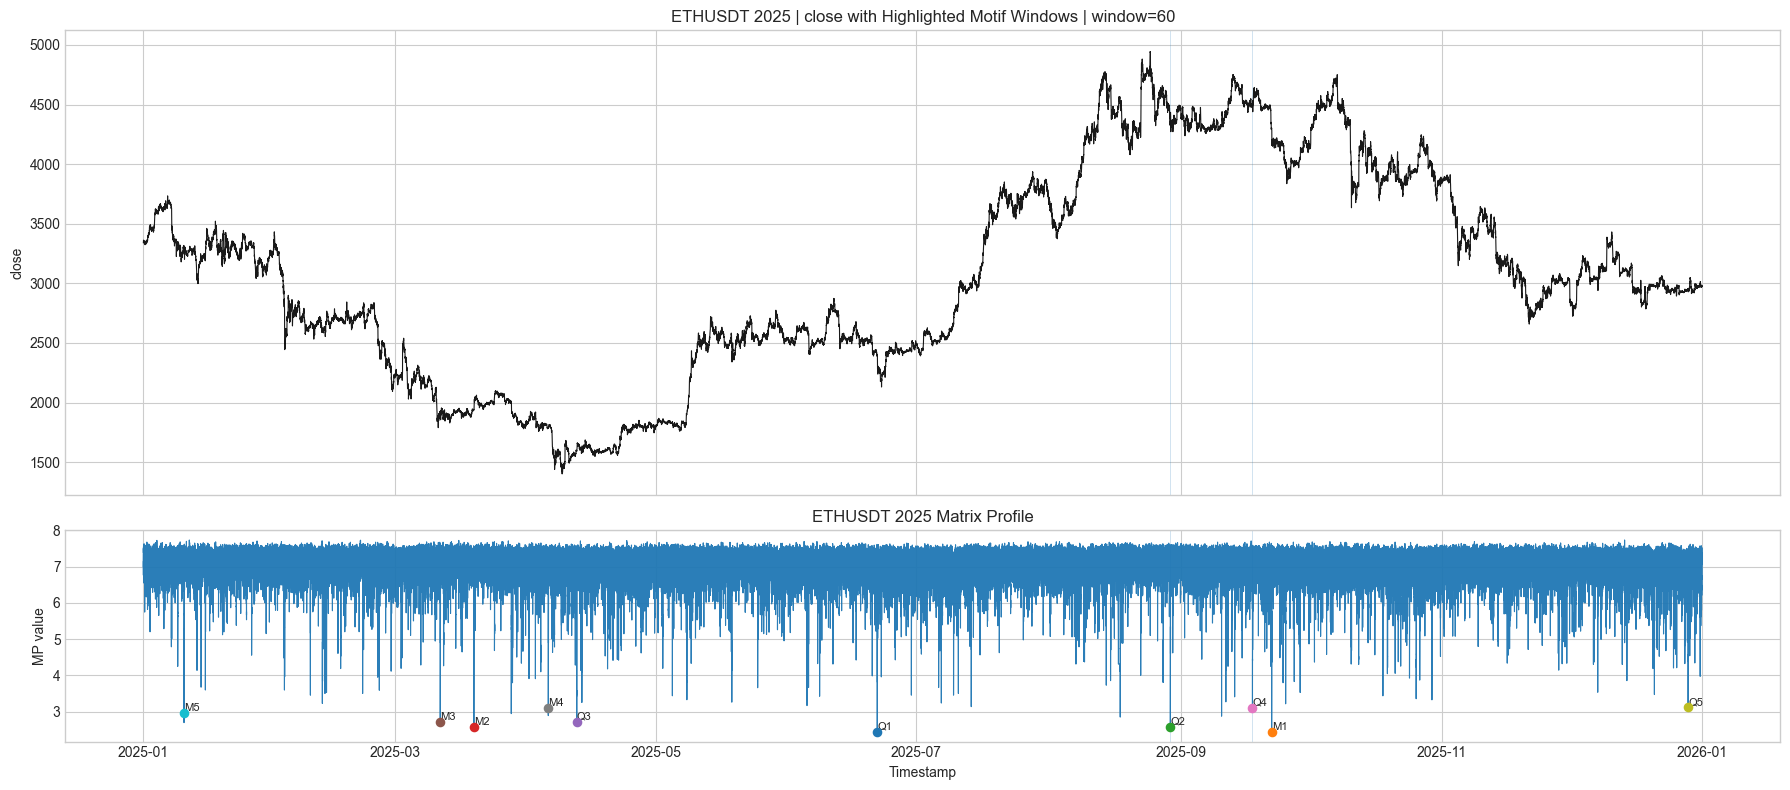

,rank,query_time,match_time,profile_value
0,1,2025-06-21 20:25:00+00:00,2025-09-22 05:00:00+00:00,2.438902
1,2,2025-08-29 11:32:00+00:00,2025-03-19 09:33:00+00:00,2.586063
2,3,2025-04-12 11:40:00+00:00,2025-03-11 12:28:00+00:00,2.725123
3,4,2025-09-17 17:01:00+00:00,2025-04-05 19:43:00+00:00,3.102971
4,5,2025-12-28 17:19:00+00:00,2025-01-10 12:34:00+00:00,3.122049


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_year_motif_overview(
    df,
    matrix_profile,
    motif_df,
    window,
    asset_name="Asset",
    value_col="close",          # can be "close" or "signal"
    top_k=5,
    downsample_step=15,
    figsize=(18, 8),
    mp_color="tab:blue",
    ts_color="black"
):
    """
    Plot a full-year overview with:
    - top panel: time series
    - bottom panel: matrix profile
    - shaded motif windows for top_k motifs

    Parameters
    ----------
    df : pd.DataFrame
        Must contain 'timestamp' and value_col.
    matrix_profile : np.ndarray
        Matrix profile array aligned to subsequence start indices.
    motif_df : pd.DataFrame
        Must contain:
        - rank
        - query_index
        - match_index
        - profile_value
        - query_time
        - match_time
    window : int
        Subsequence length in samples.
    asset_name : str
        Title label.
    value_col : str
        Column to plot on the top panel.
    top_k : int
        Number of motifs to highlight.
    downsample_step : int
        Plot every Nth point for the top time series for readability.
    """

    if df.empty:
        print(f"{asset_name}: dataframe is empty.")
        return

    if motif_df is None or motif_df.empty:
        print(f"{asset_name}: motif_df is empty.")
        return

    if value_col not in df.columns:
        raise ValueError(f"{value_col} not found in dataframe columns: {df.columns.tolist()}")

    df_plot = df.iloc[::downsample_step].copy() if downsample_step > 1 else df.copy()

    ts_full = df["timestamp"].iloc[:len(matrix_profile)]
    ts_plot = df_plot["timestamp"]
    y_plot = df_plot[value_col]

    fig, axes = plt.subplots(
        2, 1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1]}
    )

    ax_top, ax_bottom = axes

    # Top: price or signal
    ax_top.plot(ts_plot, y_plot, linewidth=0.8, color=ts_color, alpha=0.9)
    ax_top.set_title(f"{asset_name} 2025 | {value_col} with Highlighted Motif Windows | window={window}")
    ax_top.set_ylabel(value_col)

    # Bottom: matrix profile
    ax_bottom.plot(ts_full, matrix_profile, linewidth=0.8, color=mp_color, alpha=0.95)
    ax_bottom.set_title(f"{asset_name} 2025 Matrix Profile")
    ax_bottom.set_ylabel("MP value")
    ax_bottom.set_xlabel("Timestamp")

    # Highlight motifs
    motif_subset = motif_df.sort_values("rank").head(top_k).copy()

    for _, row in motif_subset.iterrows():
        q_idx = int(row["query_index"])
        m_idx = int(row["match_index"])
        rank = int(row["rank"])

        q_start = df.iloc[q_idx]["timestamp"]
        q_end = df.iloc[min(q_idx + window - 1, len(df) - 1)]["timestamp"]

        m_start = df.iloc[m_idx]["timestamp"]
        m_end = df.iloc[min(m_idx + window - 1, len(df) - 1)]["timestamp"]

        # top panel spans
        ax_top.axvspan(q_start, q_end, alpha=0.20, label=f"Motif {rank} Query" if rank == 1 else None)
        ax_top.axvspan(m_start, m_end, alpha=0.20, linestyle="--", label=f"Motif {rank} Match" if rank == 1 else None)

        # bottom panel spans
        ax_bottom.axvspan(q_start, q_end, alpha=0.20)
        ax_bottom.axvspan(m_start, m_end, alpha=0.20)

        # mark MP values at query and match starts when valid
        if q_idx < len(matrix_profile):
            ax_bottom.scatter(df.iloc[q_idx]["timestamp"], matrix_profile[q_idx], s=35, zorder=5)
            ax_bottom.text(
                df.iloc[q_idx]["timestamp"],
                matrix_profile[q_idx],
                f"Q{rank}",
                fontsize=8,
                ha="left",
                va="bottom"
            )

        if m_idx < len(matrix_profile):
            ax_bottom.scatter(df.iloc[m_idx]["timestamp"], matrix_profile[m_idx], s=35, zorder=5)
            ax_bottom.text(
                df.iloc[m_idx]["timestamp"],
                matrix_profile[m_idx],
                f"M{rank}",
                fontsize=8,
                ha="left",
                va="bottom"
            )

    plt.tight_layout()
    plt.show()

    # small summary table
    summary_cols = ["rank", "query_time", "match_time", "profile_value"]
    display(motif_subset[summary_cols])


# BTC view
plot_year_motif_overview(
    df=sample_df,
    matrix_profile=matrix_profile,
    motif_df=motif_df,
    window=window,
    asset_name="BTCUSDT",
    value_col="close" if "close" in sample_df.columns else "signal",
    top_k=5,
    downsample_step=15
)

# ETH view
plot_year_motif_overview(
    df=sample_df_eth,
    matrix_profile=matrix_profile_eth,
    motif_df=motif_df_eth,
    window=eth_window,
    asset_name="ETHUSDT",
    value_col="close" if "close" in sample_df_eth.columns else "signal",
    top_k=5,
    downsample_step=15
)

### Now for the discords


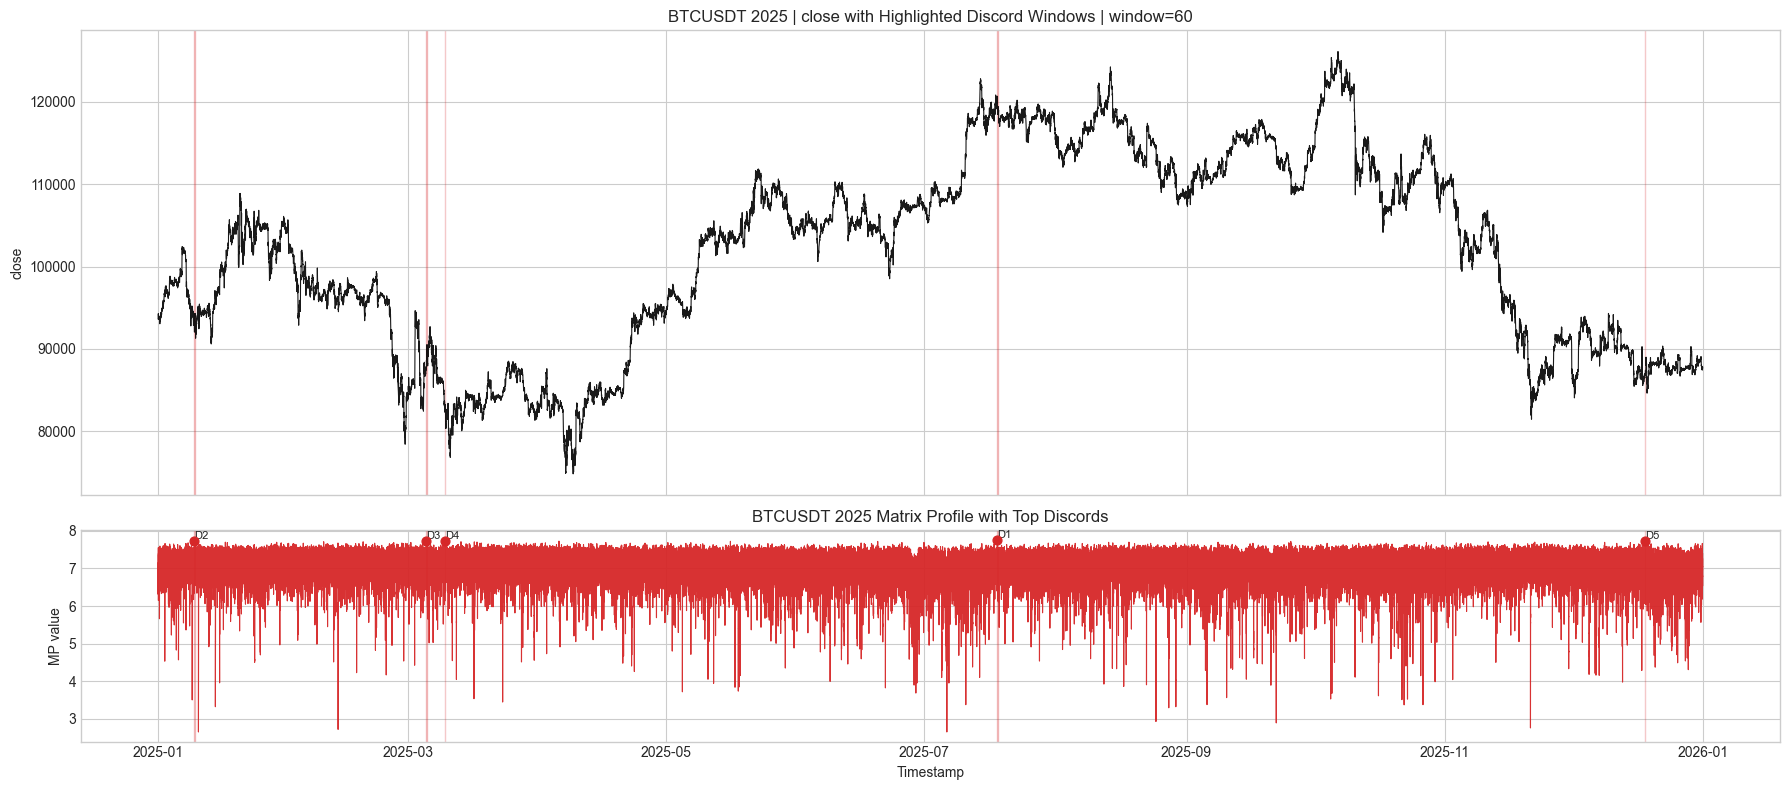

,rank,index,timestamp,profile_value
0,1,285557,2025-07-18 07:17:00+00:00,7.756587
1,2,12356,2025-01-09 13:56:00+00:00,7.742789
2,3,91260,2025-03-05 09:00:00+00:00,7.733290
3,4,97604,2025-03-09 18:44:00+00:00,7.730010
4,5,505923,2025-12-18 08:03:00+00:00,7.728219


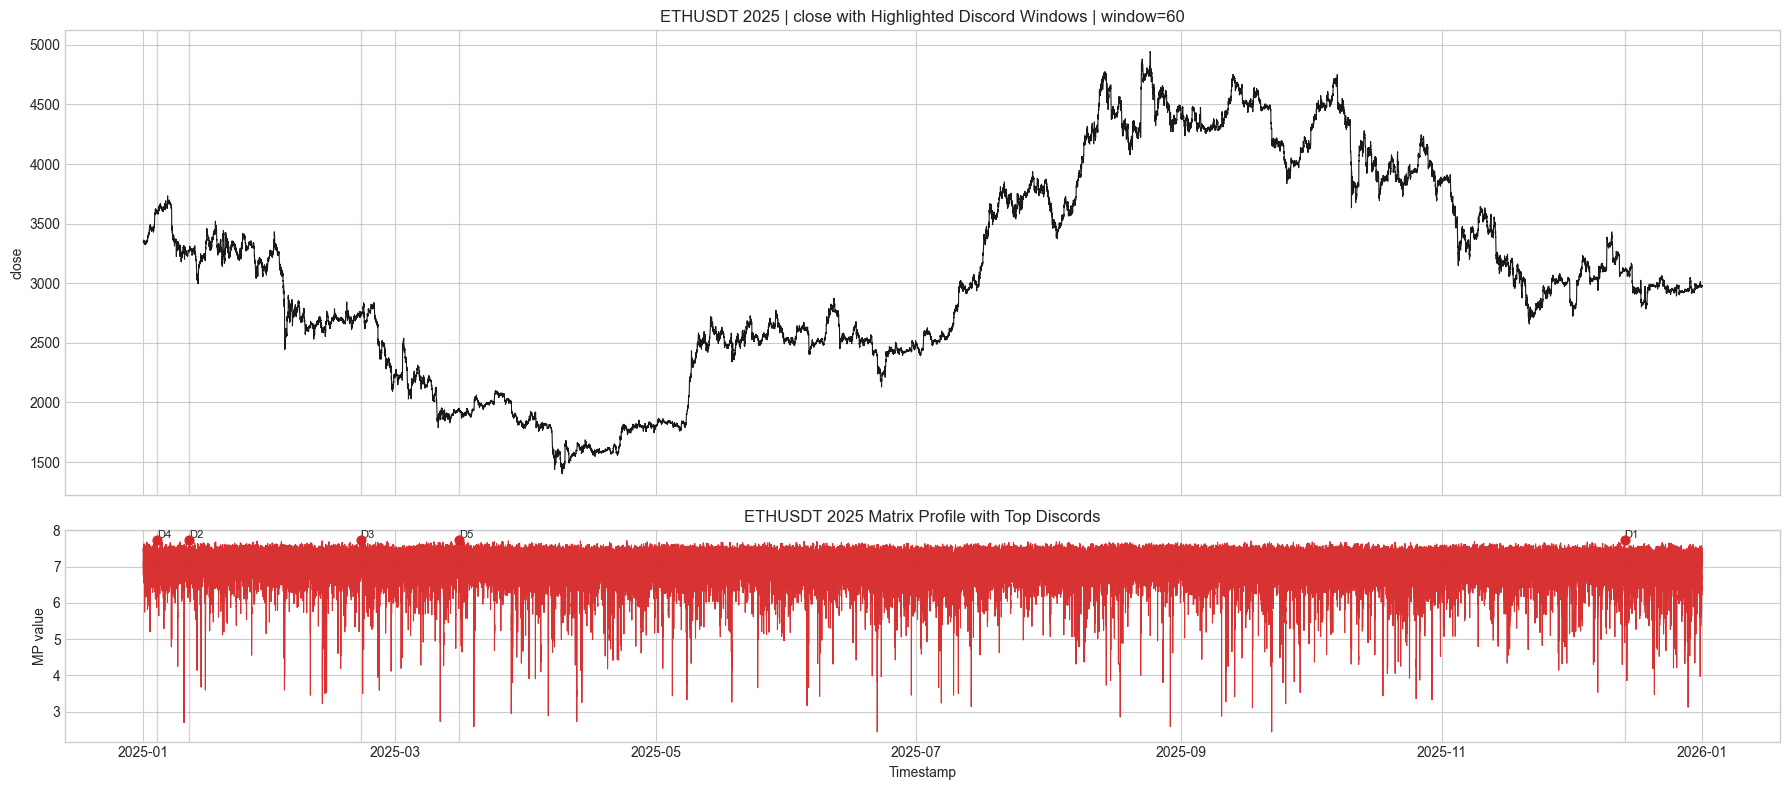

,rank,index,timestamp,profile_value
0,1,499461,2025-12-13 20:21:00+00:00,7.736598
1,2,15499,2025-01-11 18:19:00+00:00,7.736192
2,3,73226,2025-02-20 20:26:00+00:00,7.731088
3,4,4565,2025-01-04 04:05:00+00:00,7.725218
4,5,106357,2025-03-15 20:37:00+00:00,7.724433


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _resolve_discord_index_col(discord_df):
    candidates = ["index", "discord_index", "query_index"]
    for c in candidates:
        if c in discord_df.columns:
            return c
    raise ValueError(f"Could not find discord index column. Available columns: {discord_df.columns.tolist()}")

def _resolve_discord_time_col(discord_df):
    candidates = ["timestamp", "discord_time", "query_time"]
    for c in candidates:
        if c in discord_df.columns:
            return c
    return None

def plot_year_discord_overview(
    df,
    matrix_profile,
    discord_df,
    window,
    asset_name="Asset",
    value_col="close",
    top_k=5,
    downsample_step=15,
    figsize=(18, 8),
    ts_color="black",
    mp_color="tab:red"
):
    """
    Full-year overview for top discords:
    - top panel: time series
    - bottom panel: matrix profile
    - highlighted anomalous windows
    """

    if df.empty:
        print(f"{asset_name}: dataframe is empty.")
        return

    if discord_df is None or discord_df.empty:
        print(f"{asset_name}: discord_df is empty.")
        return

    if value_col not in df.columns:
        raise ValueError(f"{value_col} not found in dataframe columns: {df.columns.tolist()}")

    idx_col = _resolve_discord_index_col(discord_df)
    time_col = _resolve_discord_time_col(discord_df)

    df_plot = df.iloc[::downsample_step].copy() if downsample_step > 1 else df.copy()
    ts_full = df["timestamp"].iloc[:len(matrix_profile)]

    fig, axes = plt.subplots(
        2, 1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1]}
    )

    ax_top, ax_bottom = axes

    # top panel
    ax_top.plot(df_plot["timestamp"], df_plot[value_col], linewidth=0.8, color=ts_color, alpha=0.9)
    ax_top.set_title(f"{asset_name} 2025 | {value_col} with Highlighted Discord Windows | window={window}")
    ax_top.set_ylabel(value_col)

    # bottom panel
    ax_bottom.plot(ts_full, matrix_profile, linewidth=0.8, color=mp_color, alpha=0.95)
    ax_bottom.set_title(f"{asset_name} 2025 Matrix Profile with Top Discords")
    ax_bottom.set_ylabel("MP value")
    ax_bottom.set_xlabel("Timestamp")

    discord_subset = discord_df.sort_values("profile_value", ascending=False).head(top_k).copy()

    for rank_plot, (_, row) in enumerate(discord_subset.iterrows(), start=1):
        d_idx = int(row[idx_col])

        d_start = df.iloc[d_idx]["timestamp"]
        d_end = df.iloc[min(d_idx + window - 1, len(df) - 1)]["timestamp"]

        # highlight anomalous window
        ax_top.axvspan(d_start, d_end, alpha=0.25, color="tab:red")
        ax_bottom.axvspan(d_start, d_end, alpha=0.25, color="tab:red")

        # mark discord on MP
        if d_idx < len(matrix_profile):
            ax_bottom.scatter(df.iloc[d_idx]["timestamp"], matrix_profile[d_idx], s=40, color="tab:red", zorder=5)
            ax_bottom.text(
                df.iloc[d_idx]["timestamp"],
                matrix_profile[d_idx],
                f"D{rank_plot}",
                fontsize=8,
                ha="left",
                va="bottom"
            )

    plt.tight_layout()
    plt.show()

    summary_cols = [c for c in ["rank", idx_col, time_col, "profile_value"] if c is not None and c in discord_subset.columns]
    display(discord_subset[summary_cols])


# BTC discord overview
plot_year_discord_overview(
    df=sample_df,
    matrix_profile=matrix_profile,
    discord_df=discord_df,
    window=window,
    asset_name="BTCUSDT",
    value_col="close" if "close" in sample_df.columns else "signal",
    top_k=5,
    downsample_step=15
)

# ETH discord overview
plot_year_discord_overview(
    df=sample_df_eth,
    matrix_profile=matrix_profile_eth,
    discord_df=discord_df_eth,
    window=eth_window,
    asset_name="ETHUSDT",
    value_col="close" if "close" in sample_df_eth.columns else "signal",
    top_k=5,
    downsample_step=15
)

for one specific discord rank

This is the clean inspection chart for a single anomaly.

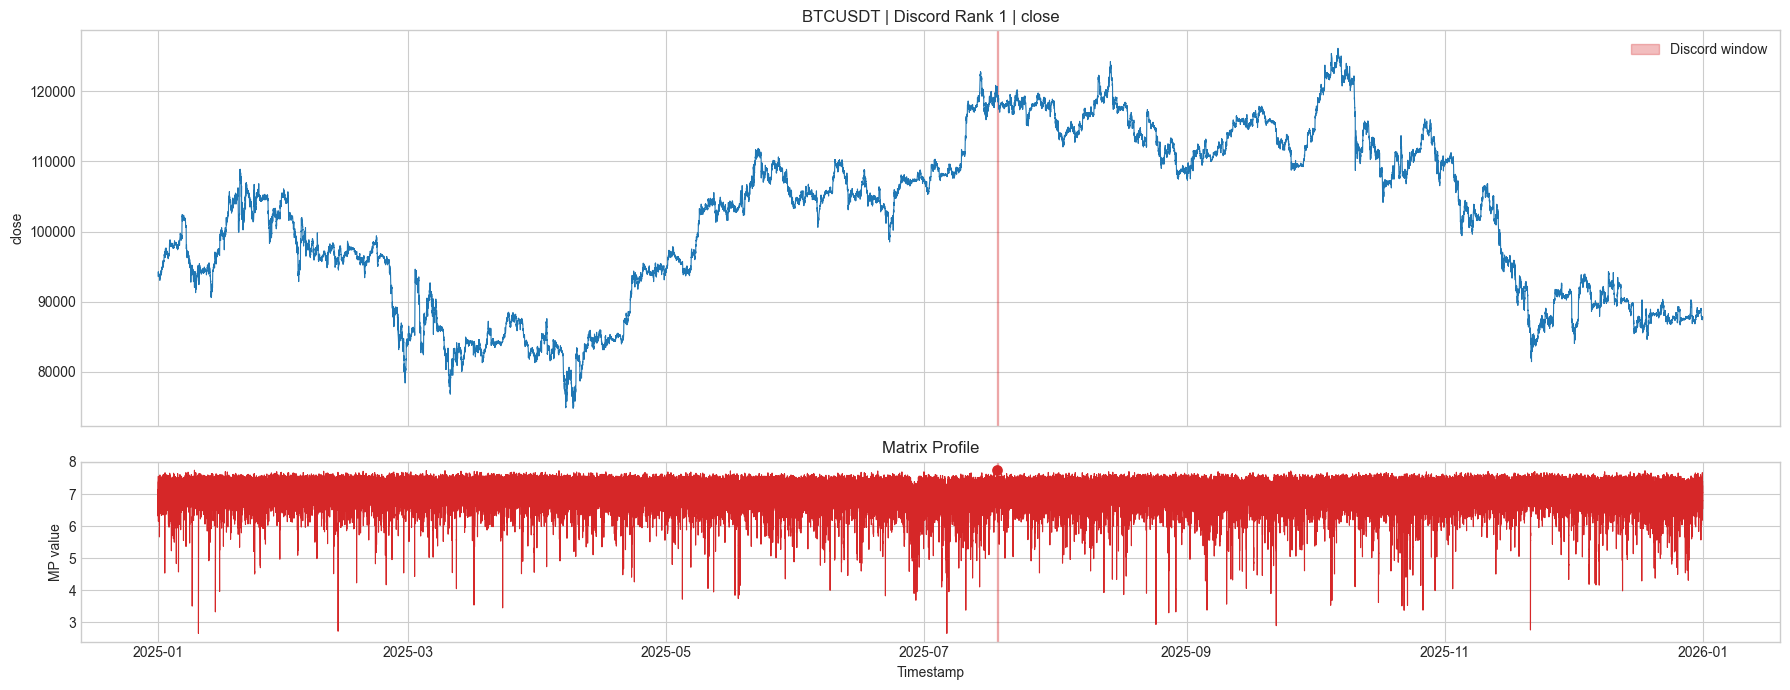

,rank,index,profile_value,timestamp,end_time
0,1,285557,7.756587,2025-07-18 07:17:00+00:00,2025-07-18 08:16:00+00:00


In [48]:
def plot_single_discord_timeline(
    df,
    matrix_profile,
    discord_df,
    window,
    discord_rank=1,
    asset_name="Asset",
    value_col="close",
    downsample_step=10,
    figsize=(18, 7)
):
    if df.empty:
        print(f"{asset_name}: dataframe is empty.")
        return

    if discord_df is None or discord_df.empty:
        print(f"{asset_name}: discord_df is empty.")
        return

    idx_col = _resolve_discord_index_col(discord_df)

    if "rank" in discord_df.columns:
        row = discord_df[discord_df["rank"] == discord_rank]
        if row.empty:
            print(f"{asset_name}: discord rank {discord_rank} not found.")
            return
        row = row.iloc[0]
    else:
        discord_sorted = discord_df.sort_values("profile_value", ascending=False).reset_index(drop=True)
        if discord_rank < 1 or discord_rank > len(discord_sorted):
            print(f"{asset_name}: discord rank {discord_rank} out of range.")
            return
        row = discord_sorted.iloc[discord_rank - 1]

    d_idx = int(row[idx_col])
    d_start = df.iloc[d_idx]["timestamp"]
    d_end = df.iloc[min(d_idx + window - 1, len(df) - 1)]["timestamp"]

    df_plot = df.iloc[::downsample_step].copy() if downsample_step > 1 else df.copy()
    ts_full = df["timestamp"].iloc[:len(matrix_profile)]

    fig, axes = plt.subplots(
        2, 1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1]}
    )

    ax_top, ax_bottom = axes

    ax_top.plot(df_plot["timestamp"], df_plot[value_col], linewidth=0.8)
    ax_top.axvspan(d_start, d_end, alpha=0.3, color="tab:red", label="Discord window")
    ax_top.set_title(f"{asset_name} | Discord Rank {discord_rank} | {value_col}")
    ax_top.set_ylabel(value_col)
    ax_top.legend()

    ax_bottom.plot(ts_full, matrix_profile, linewidth=0.8, color="tab:red")
    ax_bottom.axvspan(d_start, d_end, alpha=0.3, color="tab:red")

    if d_idx < len(matrix_profile):
        ax_bottom.scatter(df.iloc[d_idx]["timestamp"], matrix_profile[d_idx], s=45, color="tab:red", zorder=5)

    ax_bottom.set_title("Matrix Profile")
    ax_bottom.set_ylabel("MP value")
    ax_bottom.set_xlabel("Timestamp")

    plt.tight_layout()
    plt.show()

    display(pd.DataFrame([row]))


# Example usage
plot_single_discord_timeline(
    df=sample_df,
    matrix_profile=matrix_profile,
    discord_df=discord_df,
    window=window,
    discord_rank=1,
    asset_name="BTCUSDT",
    value_col="close" if "close" in sample_df.columns else "signal",
    downsample_step=15
)

comparison cell for BTC vs ETH discords summary

In [49]:
def summarize_discords(discord_df, asset_name="Asset"):
    if discord_df is None or discord_df.empty:
        return pd.DataFrame([{
            "asset": asset_name,
            "num_discords": 0,
            "max_discord_mp": np.nan,
            "median_discord_mp": np.nan
        }])

    return pd.DataFrame([{
        "asset": asset_name,
        "num_discords": len(discord_df),
        "max_discord_mp": discord_df["profile_value"].max(),
        "median_discord_mp": discord_df["profile_value"].median()
    }])

discord_summary_df = pd.concat([
    summarize_discords(discord_df, "BTC"),
    summarize_discords(discord_df_eth, "ETH")
], ignore_index=True)

discord_summary_df

,asset,num_discords,max_discord_mp,median_discord_mp
0,BTC,15,7.756587,7.719345
1,ETH,15,7.736598,7.711857


# BTC vs ETH motif intersection analysis

BTC vs ETH motif intersection analysis | tolerance = ±12 hours
BTC motif windows considered: 30
ETH motif windows considered: 30

Total BTC-ETH intersecting window pairs: 12
Unique BTC motifs participating: 9 / 15
Unique ETH motifs participating: 7 / 15

Top BTC motifs that align with ETH motifs


,btc_motif_rank,num_eth_matches
4,8,3
0,1,2
1,2,1
2,3,1
3,5,1
5,9,1
6,11,1
7,12,1
8,13,1


Top ETH motifs that align with BTC motifs


,eth_motif_rank,num_btc_matches
5,12,3
2,5,2
0,1,2
6,14,2
1,2,1
4,11,1
3,9,1


Closest BTC-ETH motif intersections


,btc_motif_rank,btc_window_type,btc_start_time,eth_motif_rank,eth_window_type,eth_start_time,time_delta_minutes
0,8,query,2025-06-21 20:25:00+00:00,1,query,2025-06-21 20:25:00+00:00,0.0
1,9,query,2025-07-06 20:32:00+00:00,12,match,2025-07-06 20:32:00+00:00,0.0
2,12,match,2025-01-15 12:31:00+00:00,12,query,2025-01-15 12:32:00+00:00,1.0
3,3,query,2025-08-29 11:31:00+00:00,2,query,2025-08-29 11:32:00+00:00,1.0
4,5,match,2025-07-10 20:18:00+00:00,9,query,2025-07-10 20:20:00+00:00,2.0
5,1,query,2025-01-10 12:31:00+00:00,5,match,2025-01-10 12:34:00+00:00,3.0
6,2,query,2025-09-22 05:03:00+00:00,1,match,2025-09-22 05:00:00+00:00,3.0
7,8,match,2025-08-27 19:22:00+00:00,14,match,2025-08-27 20:21:00+00:00,59.0
8,8,query,2025-06-21 20:25:00+00:00,14,query,2025-06-21 21:31:00+00:00,66.0
9,13,match,2025-12-28 13:43:00+00:00,5,query,2025-12-28 17:19:00+00:00,216.0


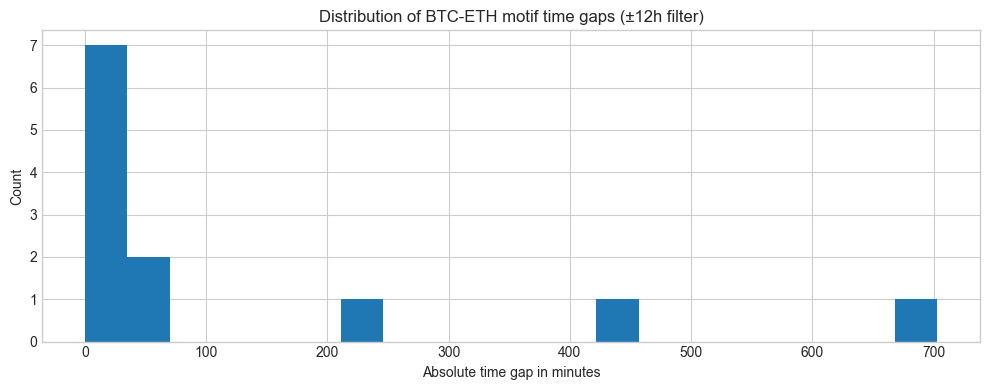

In [50]:
# BTC vs ETH motif intersection analysis
# Goal:
# Find how many BTC motif windows and ETH motif windows occur near each other in 2025

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# User controls
# =========================
tolerance_hours = 12   # change to 1, 3, 6, 12, 24 depending on how strict you want it
use_both_query_and_match_windows = True  # True = compare all motif windows, False = compare only query windows

# =========================
# Safety checks
# =========================
if motif_df.empty or motif_df_eth.empty:
    print("Need both BTC and ETH motif tables first.")
else:
    # -------------------------
    # Build event tables
    # -------------------------
    def build_motif_event_table(motif_df_local, asset_name, include_match=True):
        rows = []

        for _, row in motif_df_local.iterrows():
            # query window
            rows.append({
                "asset": asset_name,
                "motif_rank": int(row["rank"]),
                "window_type": "query",
                "start_time": pd.to_datetime(row["query_time"]),
                "end_time": pd.to_datetime(row["query_end_time"]),
                "profile_value": float(row["profile_value"]),
            })

            # match window
            if include_match:
                rows.append({
                    "asset": asset_name,
                    "motif_rank": int(row["rank"]),
                    "window_type": "match",
                    "start_time": pd.to_datetime(row["match_time"]),
                    "end_time": pd.to_datetime(row["match_end_time"]),
                    "profile_value": float(row["profile_value"]),
                })

        out = pd.DataFrame(rows).sort_values("start_time").reset_index(drop=True)
        return out

    btc_events = build_motif_event_table(motif_df, "BTC", include_match=use_both_query_and_match_windows)
    eth_events = build_motif_event_table(motif_df_eth, "ETH", include_match=use_both_query_and_match_windows)

    tolerance = pd.Timedelta(hours=tolerance_hours)

    # -------------------------
    # Pairwise nearest-time intersection logic
    # -------------------------
    intersections = []

    for _, btc_row in btc_events.iterrows():
        btc_start = btc_row["start_time"]

        for _, eth_row in eth_events.iterrows():
            eth_start = eth_row["start_time"]

            delta = abs(btc_start - eth_start)

            # strict near-in-time rule
            if delta <= tolerance:
                intersections.append({
                    "btc_motif_rank": int(btc_row["motif_rank"]),
                    "btc_window_type": btc_row["window_type"],
                    "btc_start_time": btc_row["start_time"],
                    "btc_end_time": btc_row["end_time"],
                    "btc_profile_value": btc_row["profile_value"],

                    "eth_motif_rank": int(eth_row["motif_rank"]),
                    "eth_window_type": eth_row["window_type"],
                    "eth_start_time": eth_row["start_time"],
                    "eth_end_time": eth_row["end_time"],
                    "eth_profile_value": eth_row["profile_value"],

                    "time_delta_minutes": delta.total_seconds() / 60.0
                })

    intersection_df = pd.DataFrame(intersections)

    # -------------------------
    # Summary
    # -------------------------
    print("=" * 100)
    print(f"BTC vs ETH motif intersection analysis | tolerance = ±{tolerance_hours} hours")
    print("=" * 100)
    print(f"BTC motif windows considered: {len(btc_events)}")
    print(f"ETH motif windows considered: {len(eth_events)}")

    if intersection_df.empty:
        print("\nNo BTC-ETH motif intersections found under this tolerance.")
    else:
        intersection_df = intersection_df.sort_values(
            ["time_delta_minutes", "btc_start_time", "eth_start_time"]
        ).reset_index(drop=True)

        unique_btc_motifs = intersection_df["btc_motif_rank"].nunique()
        unique_eth_motifs = intersection_df["eth_motif_rank"].nunique()

        print(f"\nTotal BTC-ETH intersecting window pairs: {len(intersection_df)}")
        print(f"Unique BTC motifs participating: {unique_btc_motifs} / {motif_df['rank'].nunique()}")
        print(f"Unique ETH motifs participating: {unique_eth_motifs} / {motif_df_eth['rank'].nunique()}")

        # motif-level participation summary
        btc_participation = (
            intersection_df.groupby("btc_motif_rank")
            .size()
            .reset_index(name="num_eth_matches")
            .sort_values("num_eth_matches", ascending=False)
        )

        eth_participation = (
            intersection_df.groupby("eth_motif_rank")
            .size()
            .reset_index(name="num_btc_matches")
            .sort_values("num_btc_matches", ascending=False)
        )

        print("\nTop BTC motifs that align with ETH motifs")
        display(btc_participation.head(10))

        print("Top ETH motifs that align with BTC motifs")
        display(eth_participation.head(10))

        print("Closest BTC-ETH motif intersections")
        display(
            intersection_df[
                [
                    "btc_motif_rank", "btc_window_type", "btc_start_time",
                    "eth_motif_rank", "eth_window_type", "eth_start_time",
                    "time_delta_minutes"
                ]
            ].head(20)
        )

        # -------------------------
        # Simple visualization
        # -------------------------
        plt.figure(figsize=(10, 4))
        plt.hist(intersection_df["time_delta_minutes"], bins=20)
        plt.title(f"Distribution of BTC-ETH motif time gaps (±{tolerance_hours}h filter)")
        plt.xlabel("Absolute time gap in minutes")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

        # Save for later thesis analysis
        intersection_output = intersection_df.copy()

a clean table of BTC-ETH common motif events

a strength classification

a date-level summary

a 24-hour comparison plot

a candlestick view for the selected anchor event


BTC vs ETH COMMON MOTIF EVENTS


,anchor_date,anchor_time,alignment_strength,time_delta_minutes,btc_motif_rank,btc_window_type,btc_start_time,btc_end_time,eth_motif_rank,eth_window_type,eth_start_time,eth_end_time,btc_profile_value,eth_profile_value
0,2025-06-21,2025-06-21 20:25:00+00:00,Very strong,0.0,8,query,2025-06-21 20:25:00+00:00,2025-06-21 21:24:00+00:00,1,query,2025-06-21 20:25:00+00:00,2025-06-21 21:24:00+00:00,3.930583,2.438902
1,2025-07-06,2025-07-06 20:32:00+00:00,Very strong,0.0,9,query,2025-07-06 20:32:00+00:00,2025-07-06 21:31:00+00:00,12,match,2025-07-06 20:32:00+00:00,2025-07-06 21:31:00+00:00,3.954404,3.597083
2,2025-01-15,2025-01-15 12:31:00+00:00,Very strong,1.0,12,match,2025-01-15 12:31:00+00:00,2025-01-15 13:30:00+00:00,12,query,2025-01-15 12:32:00+00:00,2025-01-15 13:31:00+00:00,4.259788,3.597083
3,2025-08-29,2025-08-29 11:31:00+00:00,Very strong,1.0,3,query,2025-08-29 11:31:00+00:00,2025-08-29 12:30:00+00:00,2,query,2025-08-29 11:32:00+00:00,2025-08-29 12:31:00+00:00,3.324551,2.586063
4,2025-07-10,2025-07-10 20:18:00+00:00,Very strong,2.0,5,match,2025-07-10 20:18:00+00:00,2025-07-10 21:17:00+00:00,9,query,2025-07-10 20:20:00+00:00,2025-07-10 21:19:00+00:00,3.378580,3.500333
5,2025-01-10,2025-01-10 12:31:00+00:00,Very strong,3.0,1,query,2025-01-10 12:31:00+00:00,2025-01-10 13:30:00+00:00,5,match,2025-01-10 12:34:00+00:00,2025-01-10 13:33:00+00:00,2.653183,3.122049
6,2025-09-22,2025-09-22 05:00:00+00:00,Very strong,3.0,2,query,2025-09-22 05:03:00+00:00,2025-09-22 06:02:00+00:00,1,match,2025-09-22 05:00:00+00:00,2025-09-22 05:59:00+00:00,2.931639,2.438902
7,2025-08-27,2025-08-27 19:22:00+00:00,Strong,59.0,8,match,2025-08-27 19:22:00+00:00,2025-08-27 20:21:00+00:00,14,match,2025-08-27 20:21:00+00:00,2025-08-27 21:20:00+00:00,3.930583,3.812214
8,2025-06-21,2025-06-21 20:25:00+00:00,Moderate,66.0,8,query,2025-06-21 20:25:00+00:00,2025-06-21 21:24:00+00:00,14,query,2025-06-21 21:31:00+00:00,2025-06-21 22:30:00+00:00,3.930583,3.812214
9,2025-12-28,2025-12-28 13:43:00+00:00,Weak,216.0,13,match,2025-12-28 13:43:00+00:00,2025-12-28 14:42:00+00:00,5,query,2025-12-28 17:19:00+00:00,2025-12-28 18:18:00+00:00,4.309656,3.122049



DATE-LEVEL SUMMARY OF COMMON BTC-ETH MOTIF DAYS


,anchor_date,num_intersections,closest_gap_minutes,median_gap_minutes,unique_btc_motifs,unique_eth_motifs,date_strength
2,2025-06-21,2,0.0,33.0,1,2,Very strong
3,2025-07-06,2,0.0,351.5,2,1,Very strong
1,2025-01-15,1,1.0,1.0,1,1,Very strong
6,2025-08-29,1,1.0,1.0,1,1,Very strong
4,2025-07-10,1,2.0,2.0,1,1,Very strong
0,2025-01-10,1,3.0,3.0,1,1,Very strong
7,2025-09-22,1,3.0,3.0,1,1,Very strong
5,2025-08-27,1,59.0,59.0,1,1,Strong
9,2025-12-28,1,216.0,216.0,1,1,Weak
8,2025-10-26,1,447.0,447.0,1,1,Weak



ALIGNMENT STRENGTH SUMMARY


,alignment_strength,count,min_gap_minutes,median_gap_minutes,max_gap_minutes
2,Very strong,7,0.0,1.0,3.0
1,Strong,1,59.0,59.0,59.0
0,Moderate,1,66.0,66.0,66.0
3,Weak,3,216.0,447.0,703.0



Selected anchor event for detailed validation:


,anchor_date,anchor_time,alignment_strength,time_delta_minutes,btc_motif_rank,btc_window_type,btc_start_time,btc_end_time,eth_motif_rank,eth_window_type,eth_start_time,eth_end_time,btc_profile_value,eth_profile_value
0,2025-06-21,2025-06-21 20:25:00+00:00,Very strong,0.0,8,query,2025-06-21 20:25:00+00:00,2025-06-21 21:24:00+00:00,1,query,2025-06-21 20:25:00+00:00,2025-06-21 21:24:00+00:00,3.930583,2.438902


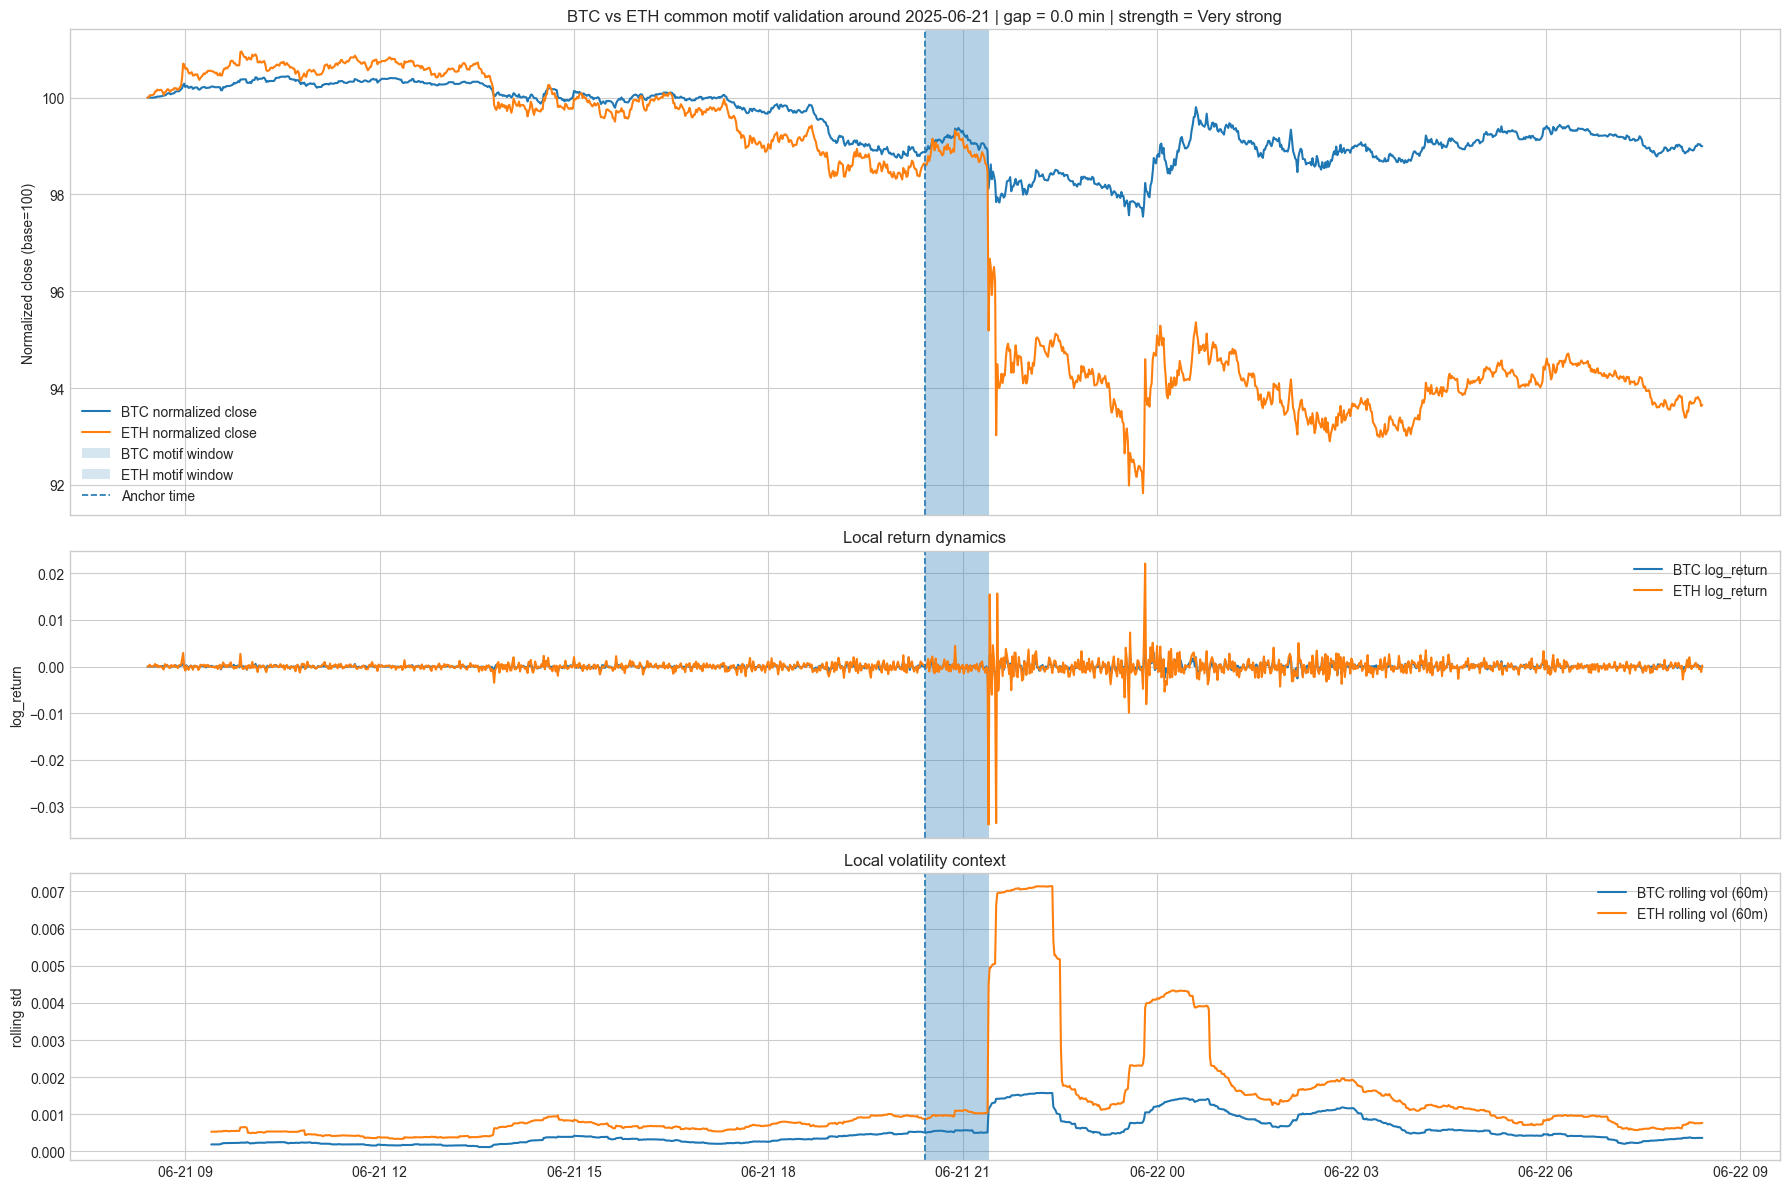

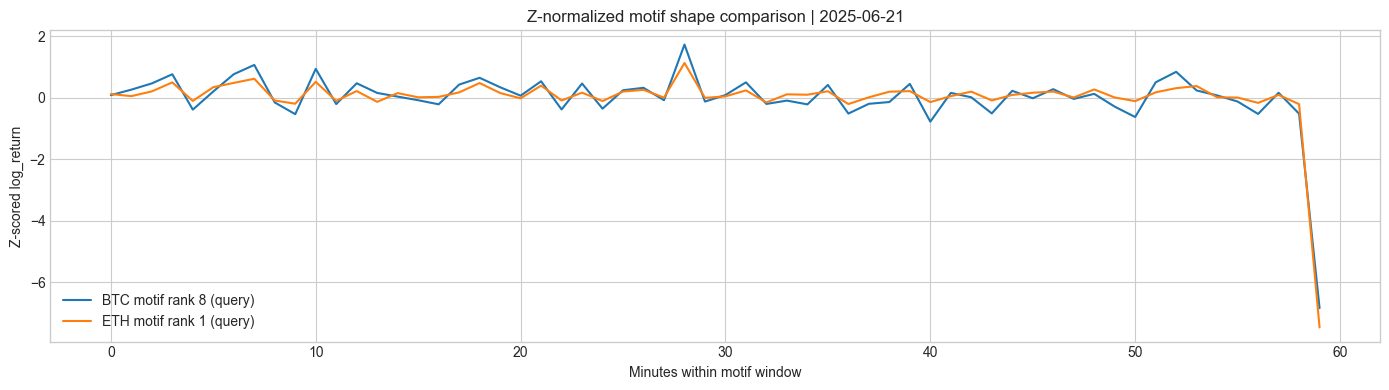

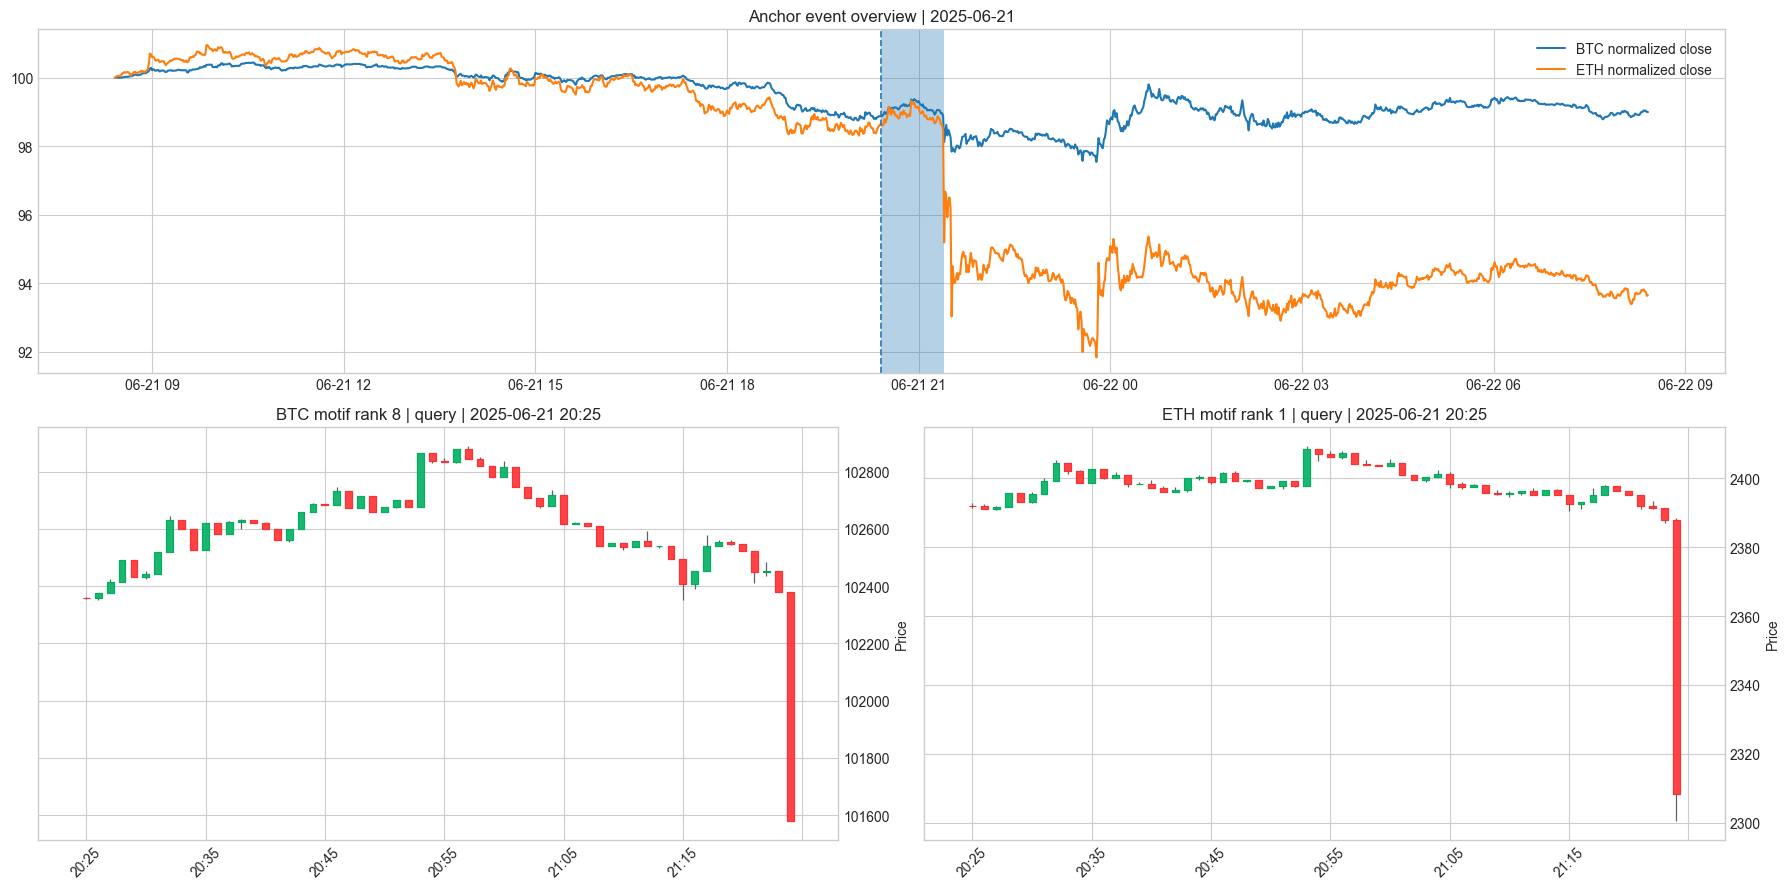


FOCUSED EVENT SUMMARY


,focus_date,alignment_strength,time_gap_minutes,btc_motif_rank,btc_window_type,btc_start_time,btc_end_time,btc_profile_value,eth_motif_rank,eth_window_type,eth_start_time,eth_end_time,eth_profile_value
0,2025-06-21,Very strong,0.0,8,query,2025-06-21 20:25:00+00:00,2025-06-21 21:24:00+00:00,3.930583,1,query,2025-06-21 20:25:00+00:00,2025-06-21 21:24:00+00:00,2.438902


In [51]:
# BTC vs ETH common motif event validation
# This cell expects:
# - intersection_output
# - sample_df, sample_df_eth
# - motif_df, motif_df_eth
# - window, eth_window
# - mplfinance installed/importable

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import mplfinance as mpf
    MPF_OK = True
except Exception:
    MPF_OK = False
    print("mplfinance not available. Candlestick plots will be skipped.")

# ============================================================
# 1. Safety checks
# ============================================================
required_objects = [
    "intersection_output", "sample_df", "sample_df_eth",
    "motif_df", "motif_df_eth", "window", "eth_window"
]
missing = [name for name in required_objects if name not in globals()]
if missing:
    raise ValueError(f"Missing required objects in notebook state: {missing}")

if intersection_output is None or intersection_output.empty:
    raise ValueError("intersection_output is empty. Run the BTC vs ETH intersection cell first.")

# ============================================================
# 2. Build a clean event table
# ============================================================
event_df = intersection_output.copy()

event_df["btc_start_time"] = pd.to_datetime(event_df["btc_start_time"], utc=True)
event_df["eth_start_time"] = pd.to_datetime(event_df["eth_start_time"], utc=True)
event_df["btc_end_time"] = pd.to_datetime(event_df["btc_end_time"], utc=True)
event_df["eth_end_time"] = pd.to_datetime(event_df["eth_end_time"], utc=True)

# Use the earlier of the two starts as a common anchor timestamp
event_df["anchor_time"] = event_df[["btc_start_time", "eth_start_time"]].min(axis=1)
event_df["anchor_date"] = event_df["anchor_time"].dt.date.astype(str)

def classify_alignment(delta_min):
    if delta_min <= 3:
        return "Very strong"
    elif delta_min <= 60:
        return "Strong"
    elif delta_min <= 180:
        return "Moderate"
    else:
        return "Weak"

event_df["alignment_strength"] = event_df["time_delta_minutes"].apply(classify_alignment)

# Clean display table
event_table = event_df[
    [
        "anchor_date",
        "anchor_time",
        "alignment_strength",
        "time_delta_minutes",
        "btc_motif_rank", "btc_window_type", "btc_start_time", "btc_end_time",
        "eth_motif_rank", "eth_window_type", "eth_start_time", "eth_end_time",
        "btc_profile_value", "eth_profile_value"
    ]
].sort_values(["time_delta_minutes", "anchor_time"]).reset_index(drop=True)

print("=" * 120)
print("BTC vs ETH COMMON MOTIF EVENTS")
print("=" * 120)
display(event_table)

# ============================================================
# 3. Date-level summary table
# ============================================================
date_summary = (
    event_table.groupby("anchor_date")
    .agg(
        num_intersections=("anchor_date", "size"),
        closest_gap_minutes=("time_delta_minutes", "min"),
        median_gap_minutes=("time_delta_minutes", "median"),
        unique_btc_motifs=("btc_motif_rank", "nunique"),
        unique_eth_motifs=("eth_motif_rank", "nunique"),
    )
    .reset_index()
    .sort_values(["closest_gap_minutes", "num_intersections"], ascending=[True, False])
)

date_summary["date_strength"] = date_summary["closest_gap_minutes"].apply(classify_alignment)

print("\n" + "=" * 120)
print("DATE-LEVEL SUMMARY OF COMMON BTC-ETH MOTIF DAYS")
print("=" * 120)
display(date_summary)

# ============================================================
# 4. Strength summary table
# ============================================================
strength_summary = (
    event_table.groupby("alignment_strength")
    .agg(
        count=("alignment_strength", "size"),
        min_gap_minutes=("time_delta_minutes", "min"),
        median_gap_minutes=("time_delta_minutes", "median"),
        max_gap_minutes=("time_delta_minutes", "max")
    )
    .reset_index()
)

strength_order = pd.CategoricalDtype(
    categories=["Very strong", "Strong", "Moderate", "Weak"],
    ordered=True
)
strength_summary["alignment_strength"] = strength_summary["alignment_strength"].astype(strength_order)
strength_summary = strength_summary.sort_values("alignment_strength")

print("\n" + "=" * 120)
print("ALIGNMENT STRENGTH SUMMARY")
print("=" * 120)
display(strength_summary)

# ============================================================
# 5. Choose anchor event to inspect
#    Default: best / closest intersection
# ============================================================
focus_row = event_table.iloc[0].copy()

# You can manually override this:
# focus_date = "2025-06-21"
# filtered = event_table[event_table["anchor_date"] == focus_date].sort_values("time_delta_minutes")
# if not filtered.empty:
#     focus_row = filtered.iloc[0].copy()

focus_date = str(focus_row["anchor_date"])
print("\nSelected anchor event for detailed validation:")
display(pd.DataFrame([focus_row]))

# ============================================================
# 6. Pull local windows around the event for BTC and ETH
# ============================================================
hours_before = 12
hours_after = 12

anchor_time = pd.to_datetime(focus_row["anchor_time"], utc=True)
plot_start = anchor_time - pd.Timedelta(hours=hours_before)
plot_end = anchor_time + pd.Timedelta(hours=hours_after)

btc_local = sample_df.loc[
    (sample_df["timestamp"] >= plot_start) & (sample_df["timestamp"] <= plot_end)
].copy()

eth_local = sample_df_eth.loc[
    (sample_df_eth["timestamp"] >= plot_start) & (sample_df_eth["timestamp"] <= plot_end)
].copy()

if btc_local.empty or eth_local.empty:
    print("One of the local windows is empty. Adjust plot range.")
else:
    # Normalize price to 100 for visual comparability
    btc_local["close_norm"] = 100 * btc_local["close"] / btc_local["close"].iloc[0]
    eth_local["close_norm"] = 100 * eth_local["close"] / eth_local["close"].iloc[0]

    # ========================================================
    # 7. Main validation figure
    # ========================================================
    fig, axes = plt.subplots(
        3, 1,
        figsize=(18, 12),
        sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1.3, 1.3]}
    )

    # ---- top: normalized close
    axes[0].plot(btc_local["timestamp"], btc_local["close_norm"], label="BTC normalized close")
    axes[0].plot(eth_local["timestamp"], eth_local["close_norm"], label="ETH normalized close")
    axes[0].axvspan(focus_row["btc_start_time"], focus_row["btc_end_time"], alpha=0.18, label="BTC motif window")
    axes[0].axvspan(focus_row["eth_start_time"], focus_row["eth_end_time"], alpha=0.18, label="ETH motif window")
    axes[0].axvline(anchor_time, linestyle="--", linewidth=1.2, label="Anchor time")
    axes[0].set_title(
        f"BTC vs ETH common motif validation around {focus_date} | "
        f"gap = {focus_row['time_delta_minutes']:.1f} min | "
        f"strength = {focus_row['alignment_strength']}"
    )
    axes[0].set_ylabel("Normalized close (base=100)")
    axes[0].legend(loc="best")

    # ---- middle: log-return signal
    axes[1].plot(btc_local["timestamp"], btc_local["signal"], label="BTC log_return")
    axes[1].plot(eth_local["timestamp"], eth_local["signal"], label="ETH log_return")
    axes[1].axvspan(focus_row["btc_start_time"], focus_row["btc_end_time"], alpha=0.18)
    axes[1].axvspan(focus_row["eth_start_time"], focus_row["eth_end_time"], alpha=0.18)
    axes[1].axvline(anchor_time, linestyle="--", linewidth=1.2)
    axes[1].set_ylabel("log_return")
    axes[1].set_title("Local return dynamics")
    axes[1].legend(loc="best")

    # ---- bottom: rolling realized volatility proxy
    btc_local = btc_local.copy()
    eth_local = eth_local.copy()
    btc_local["rv_60"] = btc_local["signal"].rolling(60).std()
    eth_local["rv_60"] = eth_local["signal"].rolling(60).std()

    axes[2].plot(btc_local["timestamp"], btc_local["rv_60"], label="BTC rolling vol (60m)")
    axes[2].plot(eth_local["timestamp"], eth_local["rv_60"], label="ETH rolling vol (60m)")
    axes[2].axvspan(focus_row["btc_start_time"], focus_row["btc_end_time"], alpha=0.18)
    axes[2].axvspan(focus_row["eth_start_time"], focus_row["eth_end_time"], alpha=0.18)
    axes[2].axvline(anchor_time, linestyle="--", linewidth=1.2)
    axes[2].set_ylabel("rolling std")
    axes[2].set_title("Local volatility context")
    axes[2].legend(loc="best")

    plt.tight_layout()
    plt.show()

# ============================================================
# 8. Shape comparison for the selected motif pair
# ============================================================
def zscore_subseq(x):
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    if sd == 0 or np.isnan(sd):
        return np.zeros_like(x)
    return (x - mu) / sd

# Resolve BTC subsequence
btc_rank = int(focus_row["btc_motif_rank"])
eth_rank = int(focus_row["eth_motif_rank"])

btc_motif_row = motif_df.loc[motif_df["rank"] == btc_rank].iloc[0]
eth_motif_row = motif_df_eth.loc[motif_df_eth["rank"] == eth_rank].iloc[0]

btc_idx_col = "query_index" if focus_row["btc_window_type"] == "query" else "match_index"
eth_idx_col = "query_index" if focus_row["eth_window_type"] == "query" else "match_index"

btc_start_idx = int(btc_motif_row[btc_idx_col])
eth_start_idx = int(eth_motif_row[eth_idx_col])

btc_seq = sample_df["signal"].iloc[btc_start_idx : btc_start_idx + window].to_numpy()
eth_seq = sample_df_eth["signal"].iloc[eth_start_idx : eth_start_idx + eth_window].to_numpy()

min_len = min(len(btc_seq), len(eth_seq))
btc_seq = btc_seq[:min_len]
eth_seq = eth_seq[:min_len]

plt.figure(figsize=(14, 4))
plt.plot(zscore_subseq(btc_seq), label=f"BTC motif rank {btc_rank} ({focus_row['btc_window_type']})")
plt.plot(zscore_subseq(eth_seq), label=f"ETH motif rank {eth_rank} ({focus_row['eth_window_type']})")
plt.title(f"Z-normalized motif shape comparison | {focus_date}")
plt.xlabel("Minutes within motif window")
plt.ylabel("Z-scored log_return")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 9. Candlestick inspection for selected motif windows
# ============================================================
if MPF_OK:
    fig = plt.figure(figsize=(18, 9))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

    # Top panel: full local normalized price
    ax_top = fig.add_subplot(gs[0, :])
    ax_top.plot(btc_local["timestamp"], btc_local["close_norm"], label="BTC normalized close")
    ax_top.plot(eth_local["timestamp"], eth_local["close_norm"], label="ETH normalized close")
    ax_top.axvspan(focus_row["btc_start_time"], focus_row["btc_end_time"], alpha=0.18)
    ax_top.axvspan(focus_row["eth_start_time"], focus_row["eth_end_time"], alpha=0.18)
    ax_top.axvline(anchor_time, linestyle="--", linewidth=1.2)
    ax_top.set_title(f"Anchor event overview | {focus_date}")
    ax_top.legend(loc="best")

    # BTC candle
    ax_btc = fig.add_subplot(gs[1, 0])
    btc_ohlc = sample_df.iloc[btc_start_idx : btc_start_idx + window].copy()
    btc_ohlc = btc_ohlc.set_index("timestamp")[["open", "high", "low", "close", "volume"]]
    mpf.plot(btc_ohlc, type="candle", ax=ax_btc, volume=False, style="yahoo")
    ax_btc.set_title(
        f"BTC motif rank {btc_rank} | {focus_row['btc_window_type']} | "
        f"{focus_row['btc_start_time']:%Y-%m-%d %H:%M}"
    )

    # ETH candle
    ax_eth = fig.add_subplot(gs[1, 1])
    eth_ohlc = sample_df_eth.iloc[eth_start_idx : eth_start_idx + eth_window].copy()
    eth_ohlc = eth_ohlc.set_index("timestamp")[["open", "high", "low", "close", "volume"]]
    mpf.plot(eth_ohlc, type="candle", ax=ax_eth, volume=False, style="yahoo")
    ax_eth.set_title(
        f"ETH motif rank {eth_rank} | {focus_row['eth_window_type']} | "
        f"{focus_row['eth_start_time']:%Y-%m-%d %H:%M}"
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# 10. Thesis-ready compact summary table for the chosen event
# ============================================================
focus_summary = pd.DataFrame([{
    "focus_date": focus_date,
    "alignment_strength": focus_row["alignment_strength"],
    "time_gap_minutes": focus_row["time_delta_minutes"],
    "btc_motif_rank": btc_rank,
    "btc_window_type": focus_row["btc_window_type"],
    "btc_start_time": focus_row["btc_start_time"],
    "btc_end_time": focus_row["btc_end_time"],
    "btc_profile_value": focus_row["btc_profile_value"],
    "eth_motif_rank": eth_rank,
    "eth_window_type": focus_row["eth_window_type"],
    "eth_start_time": focus_row["eth_start_time"],
    "eth_end_time": focus_row["eth_end_time"],
    "eth_profile_value": focus_row["eth_profile_value"],
}])

print("\n" + "=" * 120)
print("FOCUSED EVENT SUMMARY")
print("=" * 120)
display(focus_summary)